# **SISTEM PENDUKUNG KEPUTUSAN PRIORITAS PENANGANAN KEMISKINAN MENGGUNAKAN FUZZY WASPAS MELALUI FUZZY AHP DI KABUPATEN PONOROGO**
**1. Fuzzy AHP**


**2. Fuzzy WASPAS**

## 1. Import Library

In [1]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import math
from sklearn.cluster import KMeans
import random
from math import pi
import matplotlib.colors as mcolors

## 2. Read Data

In [2]:
data = pd.read_excel('data_kemiskinan_14-20.xlsx')

In [3]:
#menampilkan nama kolom
print('Nama Kolom Dalam Dataset:')
for col in data.columns:
    print(col)

Nama Kolom Dalam Dataset:
No
Kecamatan
Desa Kelurahan
Alamat
Kepala Keluarga
Padan Dukcapil
Jenis Kelamin
Tanggal Lahir
Pekerjaan
Pendidikan
Kepemilikan Rumah
Simpanan
Jenis Atap
Jenis Dinding
Jenis Lantai
Sumber Penerangan
Bahan Bakar Memasak
Sumber Air Minum
Fasilitas BAB
PenerimaBPNT
PenerimaBPUM
PenerimaBST
PenerimaPKH
PenerimaSEMBAKO
Stunting
rtlh
percentile
Pendapatan
Frekuensi Makan Per Hari
Frekuensi Beli Pakaian
Frekuensi Makan Daging Susu Ayam
Luas Lantai
Akses Berobat


In [4]:
#menampilkan jumlah kolom dan baris
num_rows, num_cols = data.shape

print(f'Jumlah Baris: {num_rows}')
print(f'Jumlah Kolom: {num_cols}')

Jumlah Baris: 20000
Jumlah Kolom: 33


## 3. Prepocessing Data

a. Menampilkan informasi dataset

In [5]:
#menampilkan info dataset
print('Tipe Data Setiap Kolom:')
data.info()

Tipe Data Setiap Kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   No                                20000 non-null  int64 
 1   Kecamatan                         20000 non-null  object
 2   Desa Kelurahan                    20000 non-null  object
 3   Alamat                            19998 non-null  object
 4   Kepala Keluarga                   20000 non-null  object
 5   Padan Dukcapil                    20000 non-null  object
 6   Jenis Kelamin                     20000 non-null  object
 7   Tanggal Lahir                     20000 non-null  object
 8   Pekerjaan                         20000 non-null  object
 9   Pendidikan                        20000 non-null  object
 10  Kepemilikan Rumah                 20000 non-null  object
 11  Simpanan                          20000 non-null  object

b. Menghapus kolom yang tidak digunakan dalam analisis

In [6]:
# Daftar kolom yang ingin dihapus
kolom = ['Alamat','Padan Dukcapil','No','percentile','Jenis Kelamin','Tanggal Lahir','Pekerjaan','Kepemilikan Rumah',
        'PenerimaBPNT','PenerimaBPUM','PenerimaBST','PenerimaPKH','PenerimaSEMBAKO','rtlh','Jenis Atap','Stunting']
data = data.drop(columns=kolom)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Kecamatan                         20000 non-null  object
 1   Desa Kelurahan                    20000 non-null  object
 2   Kepala Keluarga                   20000 non-null  object
 3   Pendidikan                        20000 non-null  object
 4   Simpanan                          20000 non-null  object
 5   Jenis Dinding                     20000 non-null  object
 6   Jenis Lantai                      20000 non-null  object
 7   Sumber Penerangan                 20000 non-null  object
 8   Bahan Bakar Memasak               20000 non-null  object
 9   Sumber Air Minum                  20000 non-null  object
 10  Fasilitas BAB                     20000 non-null  object
 11  Pendapatan                        20000 non-null  int64 
 12  Frekuensi Makan Pe

c. Pengecekan missing value

In [8]:
#deteksi missing value disetiap kolom
nan = data.isna().sum()

print('Jumlah Missing Value Setiap Kolom:')
nan

Jumlah Missing Value Setiap Kolom:


Kecamatan                           0
Desa Kelurahan                      0
Kepala Keluarga                     0
Pendidikan                          0
Simpanan                            0
Jenis Dinding                       0
Jenis Lantai                        0
Sumber Penerangan                   0
Bahan Bakar Memasak                 0
Sumber Air Minum                    0
Fasilitas BAB                       0
Pendapatan                          0
Frekuensi Makan Per Hari            0
Frekuensi Beli Pakaian              0
Frekuensi Makan Daging Susu Ayam    0
Luas Lantai                         0
Akses Berobat                       0
dtype: int64

In [9]:
data.to_excel('data_kemiskinan_ponorogo.xlsx', index=False, engine='openpyxl')
print("Data berhasil disimpan")

Data berhasil disimpan


In [10]:
data2 = data.copy()

g. Mengubah data berdasarkan skor

In [11]:
# Pendidikan
data2['Pendidikan'] = data2['Pendidikan'].map({
    'Tidak/belum sekolah': 5,
    'Tidak tamat SD/sederajat': 5,
    'Siswa SD/sederajat': 4,
    'Tamat SD/sederajat': 4,
    'Siswa SMP/sederajat': 3,
    'Tamat SMP/sederajat': 3,
    'Siswa SMA/sederajat': 2,
    'Tamat SMA/sederajat': 2,
    'Mahasiswa Perguruan Tinggi': 1,
    'Tamat Perguruan Tinggi': 1
})

# Jenis Dinding
data2['Jenis Dinding'] = data2['Jenis Dinding'].map({
    'Tembok': 1,
    'Seng': 2,
    'Lainnya': 2,
    'Kayu/Papan': 3,
    'Bambu': 4
})

# Jenis Lantai
data2['Jenis Lantai'] = data2['Jenis Lantai'].map({
    'Keramik/Granit/Marmer/Ubin/Tegel/Teraso': 1,
    'Semen': 2,
    'Lainnya': 3,
    'Kayu/Papan': 3,
    'Bambu': 4,
    'Tanah': 5
})

# Sumber Penerangan
data2['Sumber Penerangan'] = data2['Sumber Penerangan'].map({
    'Listrik Pribadi s/d 900 Watt': 1,
    'Listrik Pribadi > 900 Watt': 1,
    'Non-Listrik': 2,
    'Listrik Bersama': 2,
    'Genset/solar cell': 2
})

# Bahan Bakar Memasak
data2['Bahan Bakar Memasak'] = data2['Bahan Bakar Memasak'].map({
    'Listrik/Gas': 1,
    'Minyak Tanah': 2,
    'Arang/Kayu': 3,
    'Lainnya': 2
})

# Sumber Air Minum
data2['Sumber Air Minum'] = data2['Sumber Air Minum'].map({
    'Ledeng/PAM': 1,
    'Air Kemasan/Isi Ulang': 1,
    'Sumur Bor': 1,
    'Sumur Terlindung': 1,
    'Sumur Tidak Terlindung': 2,
    'Air Permukaan (Sungai, Danau, dll)': 3,
    'Air Hujan': 4,
    'Lainnya': 3
})

# Fasilitas BAB
data2['Fasilitas BAB'] = data2['Fasilitas BAB'].map({
    'Ya, dengan Septic Tank': 1,
    'Ya, tanpa Septic Tank': 2,
    'Lainnya': 2,
    'Tidak, Jamban Umum/Bersama': 3
})

# Simpanan
data2['Simpanan'] = data2['Simpanan'].map({
    'Ya': 1,
    'Tidak': 2
})

# Bisa berobat ke puskesmas
data2['Akses Berobat'] = data2['Akses Berobat'].map({
    True: 1,
    False: 2
})

# Pendapatan
data2['Pendapatan'] = data2['Pendapatan'].apply(lambda x: 2 if x <= 600_000 else 1)

# Luas Lantai
data2['Luas Lantai'] = data2['Luas Lantai'].apply(lambda x: 2 if x <= 8 else 1)

# Baju
data2['Frekuensi Beli Pakaian'] = data2['Frekuensi Beli Pakaian'].apply(
    lambda x: 2 if x <= 1 else 1
)

# Konsumsi daging/susu/ayam
data2['Frekuensi Makan Daging Susu Ayam'] = data2['Frekuensi Makan Daging Susu Ayam'].map({
    0 : 2,
    1 : 2,
    2 : 1,
    3 : 1,
    4 : 1,
    5 : 1
})

# Frekuensi Makan
data2['Frekuensi Makan Per Hari'] = data2['Frekuensi Makan Per Hari'].map({
    3 : 1,
    2 : 2,
    1 : 3
})

In [12]:
data2.to_excel('data_proses3.xlsx', index=False, engine='openpyxl')
print("Data berhasil disimpan")

Data berhasil disimpan


In [13]:
data3 = data2.copy()

# 4. Fuzzy AHP

## **4.1. 14 Indikator Kemiskinan Kemensos/DTKS**

C1 : makan dalam sehari

C2 : pengobatan ke puskesmas

C3 : pendapatan

C4 : sumber penerangan

C5 : bahan bakar memasak

C6 : fasilitas buang air 

C7 : makan daging

C8 : luas lantai

C9 : jenis dinding

C10 : sumber air minum

C11 : tabungan/simpanan

C12 : jenis lantai

C13 : membeli pakaian

C14 : pendidikan kepala RT

## **4.2. Klasifikasi Kriteria dan Sub Kriteria**

Klasifikasi dilakukan berdasarkan 14 indikator kemiskinan keluarga (IKK). Pengelompokan indikator kemiskinan dilakukan untuk menyusun struktur hirarki penilaian pada metode **Fuzzy Analytic Hierarchy Process (FAHP)** yang terdiri dari **Kriteria (Level 1)** dan **Sub-Kriteria (Level 2)**. Penyusunan ini mengacu pada pendekatan **kemiskinan multidimensi** yang digunakan oleh BPS, UNDP, dan Bappenas, dengan mempertimbangkan aspek hunian, utilitas dasar, ketahanan pangan, serta kondisi sosial ekonomi rumah tangga.

---

### 1. Kriteria Kualitas Hunian
**Sub-Kriteria:**
- Luas lantai  
- Jenis lantai  
- Jenis dinding  
- Fasilitas buang air  

**Keterangan:**  
Kriteria ini menggambarkan kondisi fisik tempat tinggal rumah tangga yang mencerminkan tingkat kenyamanan, kesehatan lingkungan, dan kelayakan hunian. Luas lantai dan jenis material bangunan menjadi indikator kepadatan dan kualitas rumah, sedangkan fasilitas sanitasi menunjukkan tingkat kebersihan dan kesehatan lingkungan.

---

### 2. Kriteria Akses Utilitas
**Sub-Kriteria:**
- Sumber penerangan  
- Sumber air minum  
- Bahan bakar memasak  

**Keterangan:**  
Kriteria akses utilitas mencerminkan kemampuan rumah tangga dalam mengakses layanan dasar yang mendukung kehidupan sehari-hari. Ketersediaan listrik, air bersih, dan bahan bakar memasak yang layak merupakan faktor penting dalam meningkatkan kualitas hidup dan mengurangi kerentanan sosial.

---

### 3. Kriteria Ketahanan Sandang Pangan
**Sub-Kriteria:**
- Frekuensi makan dalam sehari  
- Konsumsi daging/susu/ayam  
- Pembelian pakaian  

**Keterangan:**  
Kriteria ini menilai kemampuan rumah tangga dalam memenuhi kebutuhan dasar pangan dan sandang. Frekuensi makan dan konsumsi protein hewani mencerminkan kecukupan gizi, sedangkan kemampuan membeli pakaian menunjukkan daya beli serta keberlanjutan pemenuhan kebutuhan non-pangan dasar.

---

### 4. Kriteria Sosial Ekonomi Pendidikan
**Sub-Kriteria:**
- Pendapatan  
- Pendidikan kepala rumah tangga  
- Kemampuan berobat ke puskesmas  
- Tabungan/simpanan  

**Keterangan:**  
Kriteria ini merepresentasikan kapasitas sosial dan ekonomi rumah tangga dalam menghadapi risiko kemiskinan. Pendapatan dan kepemilikan tabungan menunjukkan ketahanan ekonomi, pendidikan kepala rumah tangga mencerminkan modal manusia, sedangkan kemampuan berobat ke fasilitas kesehatan menunjukkan akses terhadap layanan sosial dasar.

In [14]:
indikator = [
    "Frekuensi Makan Per Hari",
    "Frekuensi Makan Daging Susu Ayam",
    "Frekuensi Beli Pakaian",
    "Akses Berobat",
    "Pendapatan",
    "Simpanan",
    "Pendidikan",
    "Sumber Penerangan",
    "Bahan Bakar Memasak",
    "Sumber Air Minum",
    "Fasilitas BAB",
    "Luas Lantai",
    "Jenis Dinding",
    "Jenis Lantai"
]

# Pemetaan kriteria sesuai dengan indikator
kriteria_map = {
    # Ketahanan Pangan & Sandang
    "Frekuensi Makan Per Hari": "Sandang Pangan",
    "Frekuensi Makan Daging Susu Ayam": "Sandang Pangan",
    "Frekuensi Beli Pakaian": "Sandang Pangan",

    # Profil Sosial & Ekonomi
    "Akses Berobat": "Sosial Ekonomi Pendidikan",
    "Pendapatan": "Sosial Ekonomi Pendidikan",
    "Simpanan": "Sosial Ekonomi Pendidikan",
    "Pendidikan": "Sosial Ekonomi Pendidikan",

    # Akses Utilitas
    "Sumber Penerangan": "Akses Utilitas",
    "Bahan Bakar Memasak": "Akses Utilitas",
    "Sumber Air Minum": "Akses Utilitas",

    # Kualitas Hunian
    "Fasilitas BAB": "Kualitas Hunian",
    "Luas Lantai": "Kualitas Hunian",
    "Jenis Dinding": "Kualitas Hunian",
    "Jenis Lantai": "Kualitas Hunian"
}

# Urutan kriteria
urutan_kriteria = [
    "Sandang Pangan",
    "Sosial Ekonomi Pendidikan",
    "Akses Utilitas",
    "Kualitas Hunian"
]

# Membuat DataFrame untuk hirarki indikator dan kriteria
hirarki = pd.DataFrame({
    "Indikator": indikator,
    "Kriteria": [kriteria_map[i] for i in indikator]
})

# Mengurutkan berdasarkan Kriteria agar penomoran C1-C14 rapi per kelompok
hirarki["Kriteria"] = pd.Categorical(
    hirarki["Kriteria"],
    categories=urutan_kriteria,
    ordered=True
)
hirarki = hirarki.sort_values(by="Kriteria").reset_index(drop=True)

# Penomoran C1-C14
hirarki.insert(0, "Kode", [f"C{i+1}" for i in range(len(hirarki))])
hirarki

,Kode,Indikator,Kriteria
0,C1,Frekuensi Makan Per Hari,Sandang Pangan
1,C2,Frekuensi Makan Daging Susu Ayam,Sandang Pangan
2,C3,Frekuensi Beli Pakaian,Sandang Pangan
3,C4,Akses Berobat,Sosial Ekonomi Pendidikan
4,C5,Pendapatan,Sosial Ekonomi Pendidikan
5,C6,Simpanan,Sosial Ekonomi Pendidikan
6,C7,Pendidikan,Sosial Ekonomi Pendidikan
7,C8,Sumber Penerangan,Akses Utilitas
8,C9,Bahan Bakar Memasak,Akses Utilitas
9,C10,Sumber Air Minum,Akses Utilitas


In [15]:
urutan_indikator = [
    # Sandang Pangan (C1–C3)
    "Frekuensi Makan Per Hari",           
    "Frekuensi Makan Daging Susu Ayam",    
    "Frekuensi Beli Pakaian",        

    # Sosial Ekonomi Pendidikan (C4–C7)
    "Akses Berobat",          
    "Pendapatan",                      
    "Simpanan",                
    "Pendidikan",                      

    # Akses Utilitas (C8–C10)
    "Sumber Penerangan",               
    "Bahan Bakar Memasak",               
    "Sumber Air Minum",                  

    # Kualitas Hunian (C11–C14)
    "Fasilitas BAB",  
    "Luas Lantai",                      
    "Jenis Dinding",                    
    "Jenis Lantai"                      
]

# Kolom identitas rumah tangga
kolom_awal = ["Kepala Keluarga", "Kecamatan", "Desa Kelurahan"]

data3 = data3[kolom_awal + urutan_indikator]

In [16]:
data3.to_excel('data_jurnal1.xlsx', index=False, engine='openpyxl')
print("Data berhasil disimpan")

Data berhasil disimpan


## **4.3. Perhitungan Bobot Kriteria (Level 1)**

#skema 1

In [17]:
# label kriteria
labels = [
    "Sandang Pangan",
    "Sosial Ekonomi Pendidikan",
    "Akses Utilitas",
    "Kualitas Hunian"
]

n = len(labels)

# matriks saaty
pairwise_crisp = np.array([
    [1,   1/3, 3,   4],
    [3,   1,   5,   5],
    [1/3, 1/5, 1,   3],
    [1/4, 1/5, 1/3, 1]
])

df_saaty = pd.DataFrame(
    pairwise_crisp,
    index=labels,
    columns=labels
)

df_saaty.round(4)

,Sandang Pangan,Sosial Ekonomi Pendidikan,Akses Utilitas,Kualitas Hunian
Sandang Pangan,1.0000,0.3333,3.0000,4.0
Sosial Ekonomi Pendidikan,3.0000,1.0000,5.0000,5.0
Akses Utilitas,0.3333,0.2000,1.0000,3.0
Kualitas Hunian,0.2500,0.2000,0.3333,1.0


In [18]:
# uji konsistensi
def ahp_consistency(matrix):
    n = matrix.shape[0]
    
    eigvals, _ = np.linalg.eig(matrix)
    lambda_max = np.max(np.real(eigvals))
    
    CI = (lambda_max - n) / (n - 1)
    
    RI_table = {
        1: 0.00,
        2: 0.00,
        3: 0.58,
        4: 0.90,
        5: 1.12
    }
    
    CR = CI / RI_table[n]
    
    return lambda_max, CI, CR

lambda_max, CI, CR = ahp_consistency(pairwise_crisp)

status = "Konsisten" if CR < 0.10 else "Tidak Konsisten"

print(f"Lambda Max : {lambda_max:.4f}")
print(f"CI         : {CI:.4f}")
print(f"CR         : {CR:.4f}")
print(f"Status     : {status}")

Lambda Max : 4.1894
CI         : 0.0631
CR         : 0.0701
Status     : Konsisten


#skema 2

In [19]:
# label kriteria
labels = [
    "Sandang Pangan",
    "Sosial Ekonomi Pendidikan",
    "Akses Utilitas",
    "Kualitas Hunian"
]

n = len(labels)

# matriks saaty
pairwise_crisp1 = np.array([
    [1,   1/5, 5,   6],
    [5,   1,   7,   7],
    [1/5, 1/7, 1,   5],
    [1/6, 1/7, 1/5, 1]
])

df_saaty1 = pd.DataFrame(
    pairwise_crisp1,
    index=labels,
    columns=labels
)

df_saaty1.round(4)

,Sandang Pangan,Sosial Ekonomi Pendidikan,Akses Utilitas,Kualitas Hunian
Sandang Pangan,1.0000,0.2000,5.0,6.0
Sosial Ekonomi Pendidikan,5.0000,1.0000,7.0,7.0
Akses Utilitas,0.2000,0.1429,1.0,5.0
Kualitas Hunian,0.1667,0.1429,0.2,1.0


In [20]:
# uji konsistensi
def ahp_consistency(matrix):
    n = matrix.shape[0]
    
    eigvals, _ = np.linalg.eig(matrix)
    lambda_max = np.max(np.real(eigvals))
    
    CI = (lambda_max - n) / (n - 1)
    
    RI_table = {
        1: 0.00,
        2: 0.00,
        3: 0.58,
        4: 0.90,
        5: 1.12
    }
    
    CR = CI / RI_table[n]
    
    return lambda_max, CI, CR

lambda_max, CI, CR = ahp_consistency(pairwise_crisp1)

status = "Konsisten" if CR < 0.10 else "Tidak Konsisten"

print(f"Lambda Max : {lambda_max:.4f}")
print(f"CI         : {CI:.4f}")
print(f"CR         : {CR:.4f}")
print(f"Status     : {status}")

Lambda Max : 4.5465
CI         : 0.1822
CR         : 0.2024
Status     : Tidak Konsisten


#skema 2

In [21]:
# konversi TFN
tfn_scale = {
    1: (1, 1, 1),
    3: (1, 3, 5),
    4: (2, 4, 6),
    5: (3, 5, 7),
    7: (5, 7, 9)
}

def reciprocal_tfn(tfn):
    l, m, u = tfn
    return (1/u, 1/m, 1/l)

fuzzy_matrix = np.empty((n, n), dtype=object)

for i in range(n):
    for j in range(n):
        val = pairwise_crisp[i, j]
        if val >= 1:
            fuzzy_matrix[i, j] = tfn_scale[int(round(val))]
        else:
            fuzzy_matrix[i, j] = reciprocal_tfn(
                tfn_scale[int(round(1 / val))]
            )

In [22]:
# Fuzzy Geometric Mean
fuzzy_gm = []

for i in range(n):
    l = np.prod([fuzzy_matrix[i, j][0] for j in range(n)]) ** (1/n)
    m = np.prod([fuzzy_matrix[i, j][1] for j in range(n)]) ** (1/n)
    u = np.prod([fuzzy_matrix[i, j][2] for j in range(n)]) ** (1/n)
    fuzzy_gm.append((l, m, u))

In [23]:
# Normalisasi Fuzzy Weight
sum_l = sum(x[0] for x in fuzzy_gm)
sum_m = sum(x[1] for x in fuzzy_gm)
sum_u = sum(x[2] for x in fuzzy_gm)

fuzzy_weights = [
    (l/sum_u, m/sum_m, u/sum_l)
    for l, m, u in fuzzy_gm
]

In [24]:
# α-Cut dan defuzzifikasi
alpha_list = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1]
lambda_opt = 0.5

rows = []

for alpha in alpha_list:
    crisp_weights = []

    for l, m, u in fuzzy_weights:
        l_alpha = l + alpha * (m - l)
        u_alpha = u - alpha * (u - m)
        w = lambda_opt * u_alpha + (1 - lambda_opt) * l_alpha
        crisp_weights.append(w)

    crisp_weights = np.array(crisp_weights)
    crisp_weights /= crisp_weights.sum()  # normalisasi akhir

    rows.append([
        alpha,
        *crisp_weights
    ])

In [25]:
columns = [
    "Alpha",
    "Sandang Pangan",
    "Sosial Ekonomi Pendidikan",
    "Akses Utilitas",
    "Kualitas Hunian"
]

df_fahp_alpha = pd.DataFrame(rows, columns=columns)

display(df_fahp_alpha.round(4))

,Alpha,Sandang Pangan,Sosial Ekonomi Pendidikan,Akses Utilitas,Kualitas Hunian
0,0.0,0.2843,0.4971,0.1391,0.0796
1,0.1,0.2828,0.5006,0.1380,0.0786
2,0.3,0.2794,0.5083,0.1357,0.0766
3,0.5,0.2755,0.5172,0.1330,0.0743
4,0.7,0.2710,0.5275,0.1299,0.0717
5,0.9,0.2656,0.5396,0.1263,0.0685
6,1.0,0.2626,0.5465,0.1242,0.0667


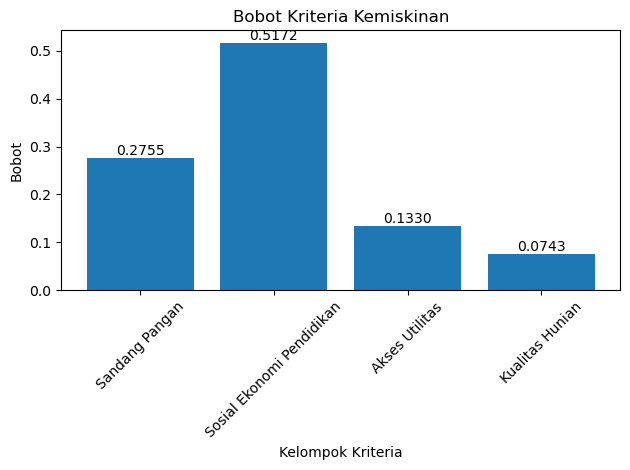

In [26]:
# Ambil baris dengan Alpha = 0.5
df_alpha_05 = df_fahp_alpha[abs(df_fahp_alpha["Alpha"] - 0.5) < 1e-6]

# Ambil nilai dan label kriteria
values = df_alpha_05.iloc[0, 1:]
labels = df_alpha_05.columns[1:]

plt.figure()
bars = plt.bar(labels, values)

plt.xticks(rotation=45)
plt.xlabel("Kelompok Kriteria")
plt.ylabel("Bobot")
plt.title("Bobot Kriteria Kemiskinan")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

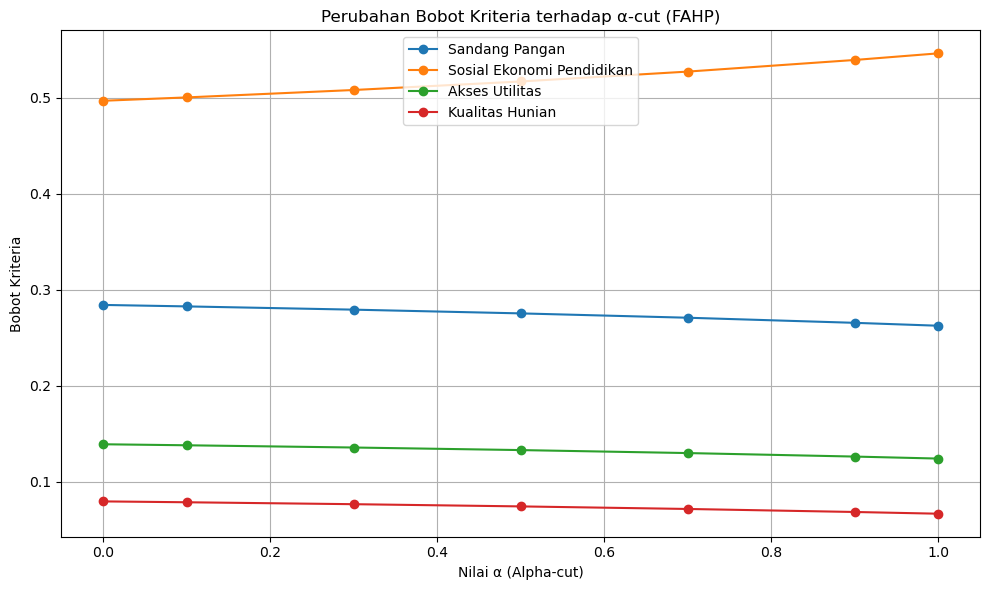

In [27]:
# Grafik Perubahan Kriteria
plt.figure(figsize=(10, 6))

for col in df_fahp_alpha.columns[1:]:
    plt.plot(
        df_fahp_alpha["Alpha"],
        df_fahp_alpha[col],
        marker='o',
        label=col
    )

plt.xlabel("Nilai α (Alpha-cut)")
plt.ylabel("Bobot Kriteria")
plt.title("Perubahan Bobot Kriteria terhadap α-cut (FAHP)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## **4.4. Perhitungan Bobot Sub Kriteria (Level 2)**

In [28]:
# Konversi TFN
def fahp_alpha_cut(pairwise_matrix, labels, alpha_list, lambda_opt=0.5):
    n = pairwise_matrix.shape[0]

    tfn_scale = {
        1: (1, 1, 1),
        2: (1, 2, 4),
        3: (1, 3, 5),
        4: (2, 4, 6),
        5: (3, 5, 7),
        7: (5, 7, 9)
    }

    def reciprocal_tfn(tfn):
        l, m, u = tfn
        return (1/u, 1/m, 1/l)

    # Crisp Fuzzy
    fuzzy_matrix = np.empty((n, n), dtype=object)
    for i in range(n):
        for j in range(n):
            val = pairwise_matrix[i, j]
            if val >= 1:
                fuzzy_matrix[i, j] = tfn_scale[int(round(val))]
            else:
                fuzzy_matrix[i, j] = reciprocal_tfn(
                    tfn_scale[int(round(1/val))]
                )

    # Fuzzy Geometric Mean
    fuzzy_gm = []
    for i in range(n):
        l = np.prod([fuzzy_matrix[i, j][0] for j in range(n)]) ** (1/n)
        m = np.prod([fuzzy_matrix[i, j][1] for j in range(n)]) ** (1/n)
        u = np.prod([fuzzy_matrix[i, j][2] for j in range(n)]) ** (1/n)
        fuzzy_gm.append((l, m, u))

    # Normalisasi
    sum_l = sum(x[0] for x in fuzzy_gm)
    sum_m = sum(x[1] for x in fuzzy_gm)
    sum_u = sum(x[2] for x in fuzzy_gm)

    fuzzy_weights = [
        (l/sum_u, m/sum_m, u/sum_l)
        for l, m, u in fuzzy_gm
    ]

    # α-Cut
    rows = []
    for alpha in alpha_list:
        crisp_w = []
        for l, m, u in fuzzy_weights:
            l_a = l + alpha * (m - l)
            u_a = u - alpha * (u - m)
            w = lambda_opt * u_a + (1 - lambda_opt) * l_a
            crisp_w.append(w)

        crisp_w = np.array(crisp_w)
        crisp_w /= crisp_w.sum()

        rows.append([alpha, *crisp_w])

    columns = ["Alpha"] + labels
    return pd.DataFrame(rows, columns=columns)

### **4.4.1. Kriteria Sandang Pangan**

In [29]:
m_pangan = np.array([
    [1, 3, 5],
    [1/3, 1, 3],
    [1/5, 1/3, 1]
])

labels_pangan = [
    "Frekuensi Makan Per Hari",
    "Frekuensi Makan Daging Susu Ayam",
    "Pembelian Beli Pakaian"
]

alpha_list = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1]

df_pangan = fahp_alpha_cut(m_pangan, labels_pangan, alpha_list)
display(df_pangan.round(4))

,Alpha,Frekuensi Makan Per Hari,Frekuensi Makan Daging Susu Ayam,Pembelian Beli Pakaian
0,0.0,0.5825,0.2940,0.1235
1,0.1,0.5865,0.2914,0.1221
2,0.3,0.5951,0.2857,0.1191
3,0.5,0.6050,0.2793,0.1157
4,0.7,0.6164,0.2718,0.1118
5,0.9,0.6296,0.2632,0.1073
6,1.0,0.6370,0.2583,0.1047


In [30]:
# uji konsistensi
def ahp_consistency(matrix):
    n = matrix.shape[0]
    
    eigvals, _ = np.linalg.eig(matrix)
    lambda_max = np.max(np.real(eigvals))
    
    CI = (lambda_max - n) / (n - 1)
    
    RI_table = {
        1: 0.00,
        2: 0.00,
        3: 0.58,
        4: 0.90,
        5: 1.12
    }
    
    CR = CI / RI_table[n]
    
    return lambda_max, CI, CR

lambda_max, CI, CR = ahp_consistency(m_pangan)

status = "Konsisten" if CR < 0.10 else "Tidak Konsisten"

print(f"Lambda Max : {lambda_max:.4f}")
print(f"CI         : {CI:.4f}")
print(f"CR         : {CR:.4f}")
print(f"Status     : {status}")

Lambda Max : 3.0385
CI         : 0.0193
CR         : 0.0332
Status     : Konsisten


### **4.4.2. Sosial Ekonomi Pendidikan**

In [31]:
m_sosek = np.array([
    [1, 2, 3, 3],
    [1/2, 1, 2, 3],
    [1/3, 1/2, 1, 2],
    [1/3, 1/3, 1/2, 1]
])

labels_sosek = [
    "Pendapatan",
    "Pendidikan",
    "Simpanan",
    "Akses Berobat"
]

df_sosek = fahp_alpha_cut(m_sosek, labels_sosek, alpha_list)
display(df_sosek.round(4))

,Alpha,Pendapatan,Pendidikan,Simpanan,Akses Berobat
0,0.0,0.4101,0.2757,0.1844,0.1297
1,0.1,0.4123,0.2763,0.1832,0.1282
2,0.3,0.4173,0.2776,0.1804,0.1247
3,0.5,0.4233,0.2791,0.1770,0.1206
4,0.7,0.4307,0.2810,0.1729,0.1155
5,0.9,0.4401,0.2834,0.1676,0.1090
6,1.0,0.4457,0.2848,0.1644,0.1051


In [32]:
# uji konsistensi
def ahp_consistency(matrix):
    n = matrix.shape[0]
    
    eigvals, _ = np.linalg.eig(matrix)
    lambda_max = np.max(np.real(eigvals))
    
    CI = (lambda_max - n) / (n - 1)
    
    RI_table = {
        1: 0.00,
        2: 0.00,
        3: 0.58,
        4: 0.90,
        5: 1.12
    }
    
    CR = CI / RI_table[n]
    
    return lambda_max, CI, CR

lambda_max, CI, CR = ahp_consistency(m_sosek)

status = "Konsisten" if CR < 0.10 else "Tidak Konsisten"

print(f"Lambda Max : {lambda_max:.4f}")
print(f"CI         : {CI:.4f}")
print(f"CR         : {CR:.4f}")
print(f"Status     : {status}")

Lambda Max : 4.0710
CI         : 0.0237
CR         : 0.0263
Status     : Konsisten


### **4.4.3. Akses Utilitas**

In [33]:
m_utilitas = np.array([
    [1, 1/2, 1/2],
    [2, 1, 1/2],
    [2, 2, 1]
])

labels_utilitas = [
    "Sumber Penerangan",
    "Bahan Bakar Memasak",
    "Sumber Air Minum"
]

df_utilitas = fahp_alpha_cut(m_utilitas, labels_utilitas, alpha_list)
display(df_utilitas.round(4))

,Alpha,Sumber Penerangan,Bahan Bakar Memasak,Sumber Air Minum
0,0.0,0.1958,0.3108,0.4934
1,0.1,0.1958,0.3108,0.4934
2,0.3,0.1958,0.3108,0.4934
3,0.5,0.1958,0.3108,0.4934
4,0.7,0.1958,0.3108,0.4934
5,0.9,0.1958,0.3108,0.4934
6,1.0,0.1958,0.3108,0.4934


In [34]:
# uji konsistensi
def ahp_consistency(matrix):
    n = matrix.shape[0]
    
    eigvals, _ = np.linalg.eig(matrix)
    lambda_max = np.max(np.real(eigvals))
    
    CI = (lambda_max - n) / (n - 1)
    
    RI_table = {
        1: 0.00,
        2: 0.00,
        3: 0.58,
        4: 0.90,
        5: 1.12
    }
    
    CR = CI / RI_table[n]
    
    return lambda_max, CI, CR

lambda_max, CI, CR = ahp_consistency(m_utilitas)

status = "Konsisten" if CR < 0.10 else "Tidak Konsisten"

print(f"Lambda Max : {lambda_max:.4f}")
print(f"CI         : {CI:.4f}")
print(f"CR         : {CR:.4f}")
print(f"Status     : {status}")

Lambda Max : 3.0536
CI         : 0.0268
CR         : 0.0462
Status     : Konsisten


### **4.4.4. Kriteria Kualitas Hunian**

In [35]:
m_hunian = np.array([
    [1, 2, 3, 4],
    [1/2, 1, 2, 3],
    [1/3, 1/2, 1, 2],
    [1/4, 1/3, 1/2, 1]
])

labels_hunian = [
    "Fasilitas BAB",
    "Jenis Lantai",
    "Luas Lantai",
    "Jenis Dinding"
]

df_hunian = fahp_alpha_cut(m_hunian, labels_hunian, alpha_list)
display(df_hunian.round(4))

,Alpha,Fasilitas BAB,Jenis Lantai,Luas Lantai,Jenis Dinding
0,0.0,0.4325,0.2742,0.1834,0.1099
1,0.1,0.4347,0.2744,0.1819,0.1089
2,0.3,0.4397,0.2749,0.1785,0.1068
3,0.5,0.4457,0.2755,0.1745,0.1043
4,0.7,0.4528,0.2762,0.1697,0.1013
5,0.9,0.4616,0.2771,0.1638,0.0975
6,1.0,0.4668,0.2776,0.1603,0.0953


In [36]:
# uji konsistensi
def ahp_consistency(matrix):
    n = matrix.shape[0]
    
    eigvals, _ = np.linalg.eig(matrix)
    lambda_max = np.max(np.real(eigvals))
    
    CI = (lambda_max - n) / (n - 1)
    
    RI_table = {
        1: 0.00,
        2: 0.00,
        3: 0.58,
        4: 0.90,
        5: 1.12
    }
    
    CR = CI / RI_table[n]
    
    return lambda_max, CI, CR

lambda_max, CI, CR = ahp_consistency(m_hunian)

status = "Konsisten" if CR < 0.10 else "Tidak Konsisten"

print(f"Lambda Max : {lambda_max:.4f}")
print(f"CI         : {CI:.4f}")
print(f"CR         : {CR:.4f}")
print(f"Status     : {status}")

Lambda Max : 4.0310
CI         : 0.0103
CR         : 0.0115
Status     : Konsisten


## **4.5. Perhitungan Bobot Global**

In [37]:
alpha_choice = 0.5

w_kriteria = (
    df_fahp_alpha
    .loc[df_fahp_alpha["Alpha"] == alpha_choice]
    .iloc[0, 1:]
)

w_kriteria

Sandang Pangan               0.275482
Sosial Ekonomi Pendidikan    0.517157
Akses Utilitas               0.133027
Kualitas Hunian              0.074335
Name: 3, dtype: float64

In [38]:
def get_sub_weights(df_sub, alpha=0.5):
    return (
        df_sub
        .loc[df_sub["Alpha"] == alpha]
        .iloc[0, 1:]
    )

w_pangan   = get_sub_weights(df_pangan, alpha_choice)
w_sosek    = get_sub_weights(df_sosek, alpha_choice)
w_utilitas = get_sub_weights(df_utilitas, alpha_choice)
w_hunian   = get_sub_weights(df_hunian, alpha_choice)

In [39]:
# bobot global
rows = []

# Ketahanan Pangan
for sub, w in w_pangan.items():
    rows.append([
        "Sandang Pangan",
        sub,
        w_kriteria["Sandang Pangan"],
        w,
        w_kriteria["Sandang Pangan"] * w
    ])

# Profil Sosial Ekonomi
for sub, w in w_sosek.items():
    rows.append([
        "Sosial Ekonomi Pendidikan",
        sub,
        w_kriteria["Sosial Ekonomi Pendidikan"],
        w,
        w_kriteria["Sosial Ekonomi Pendidikan"] * w
    ])

# Akses Utilitas
for sub, w in w_utilitas.items():
    rows.append([
        "Akses Utilitas",
        sub,
        w_kriteria["Akses Utilitas"],
        w,
        w_kriteria["Akses Utilitas"] * w
    ])

# Kualitas Hunian
for sub, w in w_hunian.items():
    rows.append([
        "Kualitas Hunian",
        sub,
        w_kriteria["Kualitas Hunian"],
        w,
        w_kriteria["Kualitas Hunian"] * w
    ])

In [40]:
df_global_weight = pd.DataFrame(
    rows,
    columns=[
        "Kriteria",
        "Sub Kriteria",
        "Bobot Kriteria",
        "Bobot Sub Kriteria",
        "Bobot Global"
    ]
)

# Normalisasi akhir 
df_global_weight["Bobot Global"] /= df_global_weight["Bobot Global"].sum()
df_global_weight

,Kriteria,Sub Kriteria,Bobot Kriteria,Bobot Sub Kriteria,Bobot Global
0,Sandang Pangan,Frekuensi Makan Per Hari,0.275482,0.605000,0.166666
1,Sandang Pangan,Frekuensi Makan Daging Susu Ayam,0.275482,0.279268,0.076933
2,Sandang Pangan,Pembelian Beli Pakaian,0.275482,0.115733,0.031882
3,Sosial Ekonomi Pendidikan,Pendapatan,0.517157,0.423311,0.218918
4,Sosial Ekonomi Pendidikan,Pendidikan,0.517157,0.279094,0.144335
5,Sosial Ekonomi Pendidikan,Simpanan,0.517157,0.177012,0.091543
6,Sosial Ekonomi Pendidikan,Akses Berobat,0.517157,0.120583,0.062360
7,Akses Utilitas,Sumber Penerangan,0.133027,0.195800,0.026047
8,Akses Utilitas,Bahan Bakar Memasak,0.133027,0.310814,0.041347
9,Akses Utilitas,Sumber Air Minum,0.133027,0.493386,0.065634


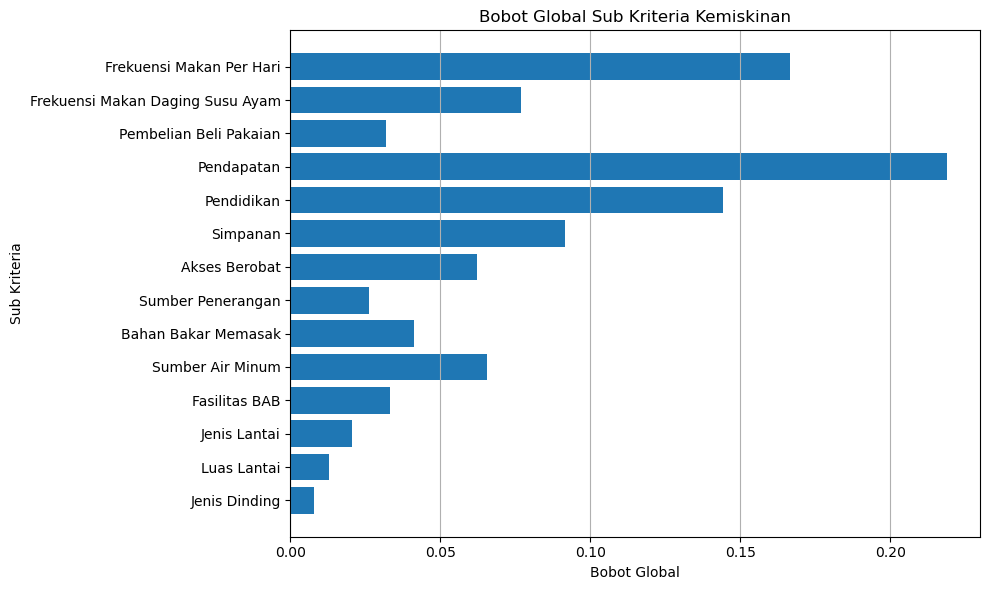

In [41]:
plt.figure(figsize=(10, 6))

plt.barh(
    df_global_weight["Sub Kriteria"],
    df_global_weight["Bobot Global"]
)

plt.xlabel("Bobot Global")
plt.ylabel("Sub Kriteria")
plt.title("Bobot Global Sub Kriteria Kemiskinan")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()
plt.show()

### Bobot Global Alpha

In [42]:
# Fungsi hitung bobot global alpha
def global_weight_for_alpha(alpha):
    w_k = (
        df_fahp_alpha
        .loc[df_fahp_alpha["Alpha"] == alpha]
        .iloc[0, 1:]
    )

    def sub_w(df):
        return (
            df.loc[df["Alpha"] == alpha]
            .iloc[0, 1:]
        )

    rows = []

    for sub, w in sub_w(df_pangan).items():
        rows.append(["Sandang Pangan", sub, w_k["Sandang Pangan"] * w])

    for sub, w in sub_w(df_sosek).items():
        rows.append(["Sosial Ekonomi Pendidikan", sub, w_k["Sosial Ekonomi Pendidikan"] * w])

    for sub, w in sub_w(df_utilitas).items():
        rows.append(["Akses Utilitas", sub, w_k["Akses Utilitas"] * w])

    for sub, w in sub_w(df_hunian).items():
        rows.append(["Kualitas Hunian", sub, w_k["Kualitas Hunian"] * w])

    df = pd.DataFrame(rows, columns=["Kriteria", "Sub Kriteria", "Bobot Global"])
    df["Bobot Global"] /= df["Bobot Global"].sum()
    return df

In [43]:
df_a01 = global_weight_for_alpha(0.1)
df_a03 = global_weight_for_alpha(0.3)
df_a05 = global_weight_for_alpha(0.5)
df_a07 = global_weight_for_alpha(0.7)

In [44]:
df_a01 = global_weight_for_alpha(0.1)
df_a01

,Kriteria,Sub Kriteria,Bobot Global
0,Sandang Pangan,Frekuensi Makan Per Hari,0.165828
1,Sandang Pangan,Frekuensi Makan Daging Susu Ayam,0.082407
2,Sandang Pangan,Pembelian Beli Pakaian,0.034529
3,Sosial Ekonomi Pendidikan,Pendapatan,0.206394
4,Sosial Ekonomi Pendidikan,Pendidikan,0.138305
5,Sosial Ekonomi Pendidikan,Simpanan,0.091692
6,Sosial Ekonomi Pendidikan,Akses Berobat,0.064167
7,Akses Utilitas,Sumber Penerangan,0.027027
8,Akses Utilitas,Bahan Bakar Memasak,0.042903
9,Akses Utilitas,Sumber Air Minum,0.068104


In [45]:
# alpha 0.9
df_a09 = global_weight_for_alpha(0.9)

# alpha 0.1 - 0.9
df_all = pd.concat([
    df_a01.assign(Alpha=0.1),
    df_a03.assign(Alpha=0.3),
    df_a05.assign(Alpha=0.5),
    df_a07.assign(Alpha=0.7),
    df_a09.assign(Alpha=0.9)
])


df_all = df_all[["Alpha", "Kriteria", "Sub Kriteria", "Bobot Global"]]
df_all

,Alpha,Kriteria,Sub Kriteria,Bobot Global
0,0.1,Sandang Pangan,Frekuensi Makan Per Hari,0.165828
1,0.1,Sandang Pangan,Frekuensi Makan Daging Susu Ayam,0.082407
2,0.1,Sandang Pangan,Pembelian Beli Pakaian,0.034529
3,0.1,Sosial Ekonomi Pendidikan,Pendapatan,0.206394
4,0.1,Sosial Ekonomi Pendidikan,Pendidikan,0.138305
...,...,...,...,...
9,0.9,Akses Utilitas,Sumber Air Minum,0.062296
10,0.9,Kualitas Hunian,Fasilitas BAB,0.031627
11,0.9,Kualitas Hunian,Jenis Lantai,0.018983
12,0.9,Kualitas Hunian,Luas Lantai,0.011221


In [46]:
df_pivot = df_all.pivot_table(
    index=["Kriteria", "Sub Kriteria"],
    columns="Alpha",
    values="Bobot Global"
).reset_index()

df_pivot

Alpha,Kriteria,Sub Kriteria,0.1,0.3,0.5,0.7,0.9
0,Akses Utilitas,Bahan Bakar Memasak,0.042903,0.042179,0.041347,0.040380,0.039244
1,Akses Utilitas,Sumber Air Minum,0.068104,0.066954,0.065634,0.064100,0.062296
2,Akses Utilitas,Sumber Penerangan,0.027027,0.026571,0.026047,0.025438,0.024722
3,Kualitas Hunian,Fasilitas BAB,0.034189,0.033700,0.033128,0.032448,0.031627
4,Kualitas Hunian,Jenis Dinding,0.008568,0.008187,0.007753,0.007256,0.006681
5,Kualitas Hunian,Jenis Lantai,0.021583,0.021070,0.020480,0.019793,0.018983
6,Kualitas Hunian,Luas Lantai,0.014305,0.013682,0.012974,0.012161,0.011221
7,Sandang Pangan,Frekuensi Makan Daging Susu Ayam,0.082407,0.079831,0.076933,0.073651,0.069906
8,Sandang Pangan,Frekuensi Makan Per Hari,0.165828,0.166263,0.166666,0.167007,0.167235
9,Sandang Pangan,Pembelian Beli Pakaian,0.034529,0.033282,0.031882,0.030300,0.028500


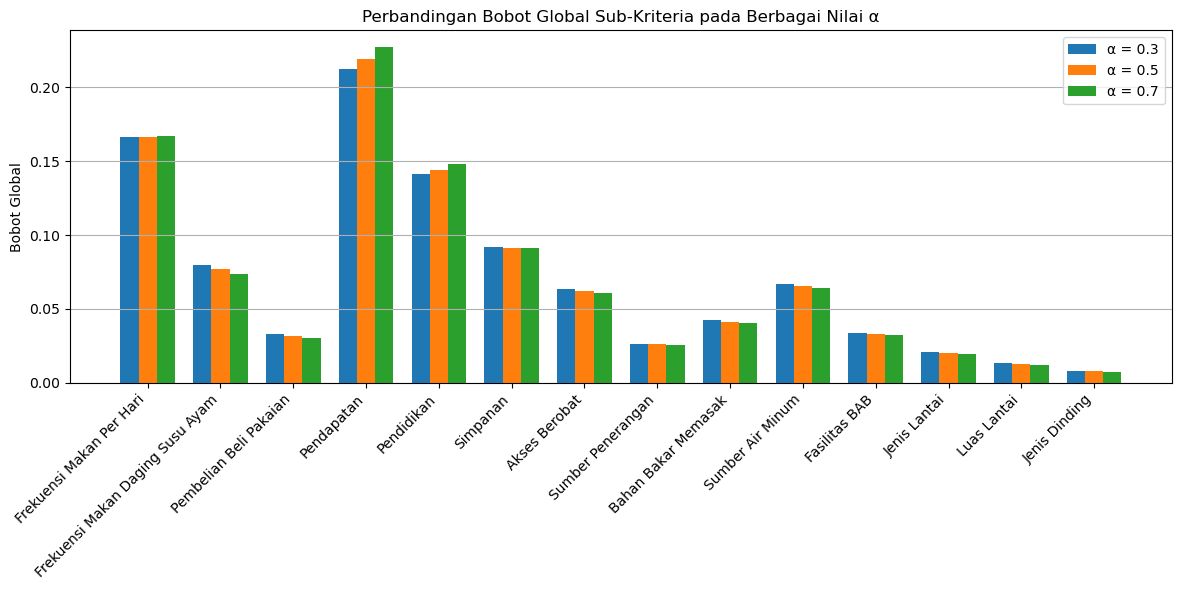

In [47]:
# Grafik Perbandingan Alpha
labels = df_a05["Sub Kriteria"]
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - width, df_a03["Bobot Global"], width, label="α = 0.3")
plt.bar(x,         df_a05["Bobot Global"], width, label="α = 0.5")
plt.bar(x + width, df_a07["Bobot Global"], width, label="α = 0.7")

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Bobot Global")
plt.title("Perbandingan Bobot Global Sub-Kriteria pada Berbagai Nilai α")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# 5. Fuzzy WASPAS

In [48]:
# Kolom identitas
id_cols = ['KepalaKeluarga', 'Kecamatan', 'DesaKelurahan']
criteria_cols = data3.columns[len(id_cols):].tolist()
X = data3[criteria_cols].copy()

In [49]:
X

,Frekuensi Makan Per Hari,Frekuensi Makan Daging Susu Ayam,Frekuensi Beli Pakaian,Akses Berobat,Pendapatan,Simpanan,Pendidikan,Sumber Penerangan,Bahan Bakar Memasak,Sumber Air Minum,Fasilitas BAB,Luas Lantai,Jenis Dinding,Jenis Lantai
0,2,2,2,2,2,2,4,1,3,1,1,2,1,2
1,3,2,2,2,2,2,5,1,3,1,1,2,1,5
2,2,1,2,2,2,2,5,1,3,1,1,2,3,5
3,3,2,2,2,2,2,5,1,3,1,1,2,3,5
4,2,2,2,1,2,2,4,1,3,3,1,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,1,1,1,1,1,1,4,1,1,1,1,1,1,1
19996,2,1,1,1,1,1,3,1,1,1,1,1,1,2
19997,2,1,1,1,1,1,4,1,1,1,1,1,1,1
19998,1,1,1,1,1,1,4,1,1,1,1,1,1,1


In [50]:
weights = dict(zip(
    criteria_cols,
    df_global_weight['Bobot Global']
))

In [51]:
tfn_scale = {
    1: (1, 1, 1),
    2: (1, 2, 4),
    3: (1, 3, 5),
    4: (2, 4, 6),
    5: (3, 5, 7),
    6: (4, 6, 8),
    7: (5, 7, 9)
}

def to_tfn(x):
    return tfn_scale.get(int(x), (1, 1, 1))

fuzzy_matrix = {}

for i in X.index:
    fuzzy_matrix[i] = {}
    for c in criteria_cols:
        fuzzy_matrix[i][c] = to_tfn(X.loc[i, c])

def normalize_fuzzy(matrix, criteria):
    norm = {}
    for c in criteria:
        max_u = max(matrix[a][c][2] for a in matrix)
        for a in matrix:
            l, m, u = matrix[a][c]
            norm.setdefault(a, {})[c] = (l/max_u, m/max_u, u/max_u)
    return norm

norm_matrix = normalize_fuzzy(fuzzy_matrix, criteria_cols)

In [52]:
max_values = {}

for c in criteria_cols:
    max_u = max(fuzzy_matrix[a][c][2] for a in fuzzy_matrix)
    max_values[c] = max_u

for k, v in max_values.items():
    print(f"{k} : {v}")

Frekuensi Makan Per Hari : 5
Frekuensi Makan Daging Susu Ayam : 4
Frekuensi Beli Pakaian : 4
Akses Berobat : 4
Pendapatan : 4
Simpanan : 4
Pendidikan : 7
Sumber Penerangan : 4
Bahan Bakar Memasak : 5
Sumber Air Minum : 6
Fasilitas BAB : 5
Luas Lantai : 4
Jenis Dinding : 6
Jenis Lantai : 7


In [53]:
def tampilkan_tfn_dan_normalisasi(idx):
    data = []
    
    for c in criteria_cols:
        # TFN awal
        l, m, u = fuzzy_matrix[idx][c]
        
        # TFN setelah normalisasi
        nl, nm, nu = norm_matrix[idx][c]
        
        data.append([
            c,
            f"({l}, {m}, {u})",
            f"({round(nl,4)}, {round(nm,4)}, {round(nu,4)})"
        ])
    
    df = pd.DataFrame(
        data,
        columns=["Sub Kriteria", "TFN Awal (l,m,u)", "TFN Normalisasi (l,m,u)"]
    )
    
    return df

In [54]:
df_alt0 = tampilkan_tfn_dan_normalisasi(0)
df_alt0

,Sub Kriteria,"TFN Awal (l,m,u)","TFN Normalisasi (l,m,u)"
0,Frekuensi Makan Per Hari,"(1, 2, 4)","(0.2, 0.4, 0.8)"
1,Frekuensi Makan Daging Susu Ayam,"(1, 2, 4)","(0.25, 0.5, 1.0)"
2,Frekuensi Beli Pakaian,"(1, 2, 4)","(0.25, 0.5, 1.0)"
3,Akses Berobat,"(1, 2, 4)","(0.25, 0.5, 1.0)"
4,Pendapatan,"(1, 2, 4)","(0.25, 0.5, 1.0)"
5,Simpanan,"(1, 2, 4)","(0.25, 0.5, 1.0)"
6,Pendidikan,"(2, 4, 6)","(0.2857, 0.5714, 0.8571)"
7,Sumber Penerangan,"(1, 1, 1)","(0.25, 0.25, 0.25)"
8,Bahan Bakar Memasak,"(1, 3, 5)","(0.2, 0.6, 1.0)"
9,Sumber Air Minum,"(1, 1, 1)","(0.1667, 0.1667, 0.1667)"


In [55]:
df_alt20 = tampilkan_tfn_dan_normalisasi(19999)
df_alt20

,Sub Kriteria,"TFN Awal (l,m,u)","TFN Normalisasi (l,m,u)"
0,Frekuensi Makan Per Hari,"(1, 2, 4)","(0.2, 0.4, 0.8)"
1,Frekuensi Makan Daging Susu Ayam,"(1, 1, 1)","(0.25, 0.25, 0.25)"
2,Frekuensi Beli Pakaian,"(1, 2, 4)","(0.25, 0.5, 1.0)"
3,Akses Berobat,"(1, 2, 4)","(0.25, 0.5, 1.0)"
4,Pendapatan,"(1, 1, 1)","(0.25, 0.25, 0.25)"
5,Simpanan,"(1, 1, 1)","(0.25, 0.25, 0.25)"
6,Pendidikan,"(1, 2, 4)","(0.1429, 0.2857, 0.5714)"
7,Sumber Penerangan,"(1, 1, 1)","(0.25, 0.25, 0.25)"
8,Bahan Bakar Memasak,"(1, 1, 1)","(0.2, 0.2, 0.2)"
9,Sumber Air Minum,"(1, 1, 1)","(0.1667, 0.1667, 0.1667)"


### Perhitungan WSM

In [56]:
def fuzzy_wsm(norm_matrix, weights):
    scores = {}
    for a in norm_matrix:
        l = m = u = 0
        for c, w in weights.items():
            nl, nm, nu = norm_matrix[a][c]
            l += nl * w
            m += nm * w
            u += nu * w
        scores[a] = (l, m, u)
    return scores

wsm_scores = fuzzy_wsm(norm_matrix, weights)

In [57]:
def tampilkan_detail_wsm_tuple(idx):
    data = []
    
    total_l = total_m = total_u = 0
    
    for c, w in weights.items():
        nl, nm, nu = norm_matrix[idx][c]
        
        # Perkalian dengan bobot
        l = nl * w
        m = nm * w
        u = nu * w
        
        total_l += l
        total_m += m
        total_u += u
        
        data.append([
            c,
            f"({round(l,4)}, {round(m,4)}, {round(u,4)})"
        ])
    
    # Tambahkan baris total
    data.append([
        "TOTAL Q1",
        f"({round(total_l,4)}, {round(total_m,4)}, {round(total_u,4)})"
    ])
    
    df = pd.DataFrame(
        data,
        columns=["Kriteria", "Hasil WSM (l,m,u)"]
    )
    
    return df

In [58]:
tampilkan_detail_wsm_tuple(0)

,Kriteria,"Hasil WSM (l,m,u)"
0,Frekuensi Makan Per Hari,"(0.0333, 0.0667, 0.1333)"
1,Frekuensi Makan Daging Susu Ayam,"(0.0192, 0.0385, 0.0769)"
2,Frekuensi Beli Pakaian,"(0.008, 0.0159, 0.0319)"
3,Akses Berobat,"(0.0547, 0.1095, 0.2189)"
4,Pendapatan,"(0.0361, 0.0722, 0.1443)"
5,Simpanan,"(0.0229, 0.0458, 0.0915)"
6,Pendidikan,"(0.0178, 0.0356, 0.0535)"
7,Sumber Penerangan,"(0.0065, 0.0065, 0.0065)"
8,Bahan Bakar Memasak,"(0.0083, 0.0248, 0.0413)"
9,Sumber Air Minum,"(0.0109, 0.0109, 0.0109)"


In [59]:
tampilkan_detail_wsm_tuple(19999)

,Kriteria,"Hasil WSM (l,m,u)"
0,Frekuensi Makan Per Hari,"(0.0333, 0.0667, 0.1333)"
1,Frekuensi Makan Daging Susu Ayam,"(0.0192, 0.0192, 0.0192)"
2,Frekuensi Beli Pakaian,"(0.008, 0.0159, 0.0319)"
3,Akses Berobat,"(0.0547, 0.1095, 0.2189)"
4,Pendapatan,"(0.0361, 0.0361, 0.0361)"
5,Simpanan,"(0.0229, 0.0229, 0.0229)"
6,Pendidikan,"(0.0089, 0.0178, 0.0356)"
7,Sumber Penerangan,"(0.0065, 0.0065, 0.0065)"
8,Bahan Bakar Memasak,"(0.0083, 0.0083, 0.0083)"
9,Sumber Air Minum,"(0.0109, 0.0109, 0.0109)"


### Perhitungan WPM

In [60]:
def fuzzy_wpm(norm_matrix, weights):
    scores = {}
    for a in norm_matrix:
        l = m = u = 1
        for c, w in weights.items():
            nl, nm, nu = norm_matrix[a][c]
            l *= nl ** w
            m *= nm ** w
            u *= nu ** w
        scores[a] = (l, m, u)
    return scores

wpm_scores = fuzzy_wpm(norm_matrix, weights)

In [61]:
def tampilkan_wpm_per_kategori(idx):
    data = []
    
    # Ambil hasil WPM untuk alternatif ke-idx
    for c in weights.keys():
        nl, nm, nu = norm_matrix[idx][c]
        w = weights[c]
        
        # Perkalian dengan bobot untuk masing-masing komponen
        l = nl ** w
        m = nm ** w
        u = nu ** w
        
        # Menambahkan hasil per kategori
        data.append([
            c,
            f"({round(l, 4)}, {round(m, 4)}, {round(u, 4)})"
        ])
    
    # Tambahkan baris total (Q₂) untuk alternatif tersebut
    total_l = total_m = total_u = 1
    for c in weights.keys():
        nl, nm, nu = norm_matrix[idx][c]
        w = weights[c]
        total_l *= nl ** w
        total_m *= nm ** w
        total_u *= nu ** w
    
    data.append([
        "TOTAL Q2",
        f"({round(total_l, 4)}, {round(total_m, 4)}, {round(total_u, 4)})"
    ])
    
    df_wpm = pd.DataFrame(data, columns=["Kriteria", "Hasil WPM (l,m,u)"])
    
    return df_wpm

tampilkan_wpm_per_kategori(0)

,Kriteria,"Hasil WPM (l,m,u)"
0,Frekuensi Makan Per Hari,"(0.7647, 0.8584, 0.9635)"
1,Frekuensi Makan Daging Susu Ayam,"(0.8988, 0.9481, 1.0)"
2,Frekuensi Beli Pakaian,"(0.9568, 0.9781, 1.0)"
3,Akses Berobat,"(0.7382, 0.8592, 1.0)"
4,Pendapatan,"(0.8187, 0.9048, 1.0)"
5,Simpanan,"(0.8808, 0.9385, 1.0)"
6,Pendidikan,"(0.9249, 0.9657, 0.9904)"
7,Sumber Penerangan,"(0.9645, 0.9645, 0.9645)"
8,Bahan Bakar Memasak,"(0.9356, 0.9791, 1.0)"
9,Sumber Air Minum,"(0.8891, 0.8891, 0.8891)"


In [62]:
tampilkan_wpm_per_kategori(19999)

,Kriteria,"Hasil WPM (l,m,u)"
0,Frekuensi Makan Per Hari,"(0.7647, 0.8584, 0.9635)"
1,Frekuensi Makan Daging Susu Ayam,"(0.8988, 0.8988, 0.8988)"
2,Frekuensi Beli Pakaian,"(0.9568, 0.9781, 1.0)"
3,Akses Berobat,"(0.7382, 0.8592, 1.0)"
4,Pendapatan,"(0.8187, 0.8187, 0.8187)"
5,Simpanan,"(0.8808, 0.8808, 0.8808)"
6,Pendidikan,"(0.8857, 0.9249, 0.9657)"
7,Sumber Penerangan,"(0.9645, 0.9645, 0.9645)"
8,Bahan Bakar Memasak,"(0.9356, 0.9356, 0.9356)"
9,Sumber Air Minum,"(0.8891, 0.8891, 0.8891)"


### Perhitungan Skor Fuzzy WASPAS

In [63]:
lambda_val = 0.5

def fuzzy_waspas(wsm, wpm, lambda_val):
    final = {}
    for a in wsm:
        l = lambda_val*wsm[a][0] + (1-lambda_val)*wpm[a][0]
        m = lambda_val*wsm[a][1] + (1-lambda_val)*wpm[a][1]
        u = lambda_val*wsm[a][2] + (1-lambda_val)*wpm[a][2]
        final[a] = (l, m, u)
    return final

final_fuzzy_scores = fuzzy_waspas(wsm_scores, wpm_scores, lambda_val)

In [64]:
def defuzzify(tfn):
    return (tfn[0] + tfn[1] + tfn[2]) / 3

result_df = pd.DataFrame({
    'Index': list(final_fuzzy_scores.keys()),
    'WSM_Fuzzy': [wsm_scores[i] for i in final_fuzzy_scores.keys()],
    'WPM_Fuzzy': [wpm_scores[i] for i in final_fuzzy_scores.keys()],
    'WASPAS_Fuzzy': [final_fuzzy_scores[i] for i in final_fuzzy_scores.keys()],
})

# Defuzzifikasi
result_df['WSM'] = result_df['WSM_Fuzzy'].apply(defuzzify)
result_df['WPM'] = result_df['WPM_Fuzzy'].apply(defuzzify)
result_df['WASPAS'] = result_df['WASPAS_Fuzzy'].apply(defuzzify)

In [65]:
final_df = (
    data3
    .reset_index()
    .merge(result_df, left_on='index', right_on='Index')
    .drop(columns=['index', 'Index'])
)

In [66]:
final_df['Rank'] = final_df['WASPAS'].rank(
    ascending=False,
    method='dense'
).astype(int)

In [67]:
score = final_df['WASPAS']

q1 = score.quantile(0.90)  # 10% 
q2 = score.quantile(0.70)  # 20% 
q3 = score.quantile(0.40)  # 30% 

def assign_cluster(score):
    if score >= q1:
        return 1   # 10% 
    elif score >= q2:
        return 2   # 20%
    elif score >= q3:
        return 3   # 30%
    else:
        return 4   # 40% 

final_df['Desil'] = score.apply(assign_cluster)

In [68]:
final_df['Desil'].value_counts().sort_index()

Desil
1    2000
2    4000
3    6000
4    8000
Name: count, dtype: int64

In [69]:
df = pd.read_excel('data_kemiskinan_ponorogo.xlsx')

In [70]:
data_gabung1 = pd.concat(
    [df.reset_index(drop=True),
     final_df[[
        'WSM_Fuzzy','WPM_Fuzzy','WASPAS_Fuzzy',
        'WSM','WPM','WASPAS','Rank','Desil'
     ]].reset_index(drop=True)],
    axis=1
)

In [71]:
data_gabung1.to_excel('data_selesai_2.xlsx', index=False, engine='openpyxl')
print("Data berhasil disimpan")

Data berhasil disimpan


In [72]:
data_gabung = data_gabung1.copy()

In [73]:
sensitivity_index = {}

for col in df_fahp_alpha.columns[1:]:
    sensitivity_index[col] = (
        df_fahp_alpha[col].max() - df_fahp_alpha[col].min()
    )

df_sensitivity_index = pd.DataFrame.from_dict(
    sensitivity_index,
    orient='index',
    columns=['Sensitivity Index']
)

display(df_sensitivity_index.round(4))

,Sensitivity Index
Sandang Pangan,0.0217
Sosial Ekonomi Pendidikan,0.0494
Akses Utilitas,0.0149
Kualitas Hunian,0.0128


### *Uji Sensitivitas Alpha terhadap Ranking Fuzzy WASPAS*

In [74]:
def fuzzy_waspas_from_weight(
    data,
    df_weight,
    id_cols,
    criteria_cols,
    tfn_scale,
    lambda_val=0.5
):

    X = data[criteria_cols].copy()

    weights = dict(zip(
        criteria_cols,
        df_weight['Bobot Global']
    ))

    def to_tfn(x):
        return tfn_scale.get(int(x), (1, 1, 1))

    fuzzy_matrix = {}
    for i in X.index:
        fuzzy_matrix[i] = {}
        for c in criteria_cols:
            fuzzy_matrix[i][c] = to_tfn(X.loc[i, c])

    def normalize_fuzzy(matrix, criteria):
        norm = {}
        for c in criteria:
            max_u = max(matrix[a][c][2] for a in matrix)
            for a in matrix:
                l, m, u = matrix[a][c]
                norm.setdefault(a, {})[c] = (l/max_u, m/max_u, u/max_u)
        return norm

    norm_matrix = normalize_fuzzy(fuzzy_matrix, criteria_cols)

    def fuzzy_wsm(norm_matrix, weights):
        scores = {}
        for a in norm_matrix:
            l = m = u = 0
            for c, w in weights.items():
                nl, nm, nu = norm_matrix[a][c]
                l += nl * w
                m += nm * w
                u += nu * w
            scores[a] = (l, m, u)
        return scores

    wsm_scores = fuzzy_wsm(norm_matrix, weights)

    def fuzzy_wpm(norm_matrix, weights):
        scores = {}
        for a in norm_matrix:
            l = m = u = 1
            for c, w in weights.items():
                nl, nm, nu = norm_matrix[a][c]
                l *= nl ** w
                m *= nm ** w
                u *= nu ** w
            scores[a] = (l, m, u)
        return scores

    wpm_scores = fuzzy_wpm(norm_matrix, weights)

    def fuzzy_waspas(wsm, wpm, lambda_val):
        final = {}
        for a in wsm:
            l = lambda_val*wsm[a][0] + (1-lambda_val)*wpm[a][0]
            m = lambda_val*wsm[a][1] + (1-lambda_val)*wpm[a][1]
            u = lambda_val*wsm[a][2] + (1-lambda_val)*wpm[a][2]
            final[a] = (l, m, u)
        return final

    final_fuzzy = fuzzy_waspas(wsm_scores, wpm_scores, lambda_val)

    def defuzzify(tfn):
        return sum(tfn) / 3

    def desil_clustering(df, score_col="WASPAS"):
        score = df[score_col]

        q1 = score.quantile(0.90)
        q2 = score.quantile(0.70)
        q3 = score.quantile(0.40)

        def assign_cluster(x):
            if x >= q1:
                return 1
            elif x >= q2:
                return 2
            elif x >= q3:
                return 3
            else:
                return 4

        return score.apply(assign_cluster)

    result_df = pd.DataFrame({
        'Index': list(final_fuzzy.keys()),
        'WSM_Fuzzy': [wsm_scores[i] for i in final_fuzzy],
        'WPM_Fuzzy': [wpm_scores[i] for i in final_fuzzy],
        'WASPAS_Fuzzy': [final_fuzzy[i] for i in final_fuzzy],
    })

    result_df['WSM'] = result_df['WSM_Fuzzy'].apply(defuzzify)
    result_df['WPM'] = result_df['WPM_Fuzzy'].apply(defuzzify)
    result_df['WASPAS'] = result_df['WASPAS_Fuzzy'].apply(defuzzify)

    result_df['Rank'] = (
        result_df['WASPAS']
        .rank(method='dense', ascending=False)
        .astype(int)
    )

    result_df['Cluster'] = desil_clustering(result_df, 'WASPAS')

    final_df = (
        data
        .reset_index()
        .merge(result_df, left_on='index', right_on='Index', how='left')
        .drop(columns=['index', 'Index'])
    )

    return final_df

In [75]:
final_df_a03 = fuzzy_waspas_from_weight(
    data=data3,
    df_weight=df_a03,
    id_cols=id_cols,
    criteria_cols=criteria_cols,
    tfn_scale=tfn_scale,
    lambda_val=0.5
)

final_df_a05 = fuzzy_waspas_from_weight(
    data=data3,
    df_weight=df_a05,
    id_cols=id_cols,
    criteria_cols=criteria_cols,
    tfn_scale=tfn_scale,
    lambda_val=0.5
)

final_df_a07 = fuzzy_waspas_from_weight(
    data=data3,
    df_weight=df_a07,
    id_cols=id_cols,
    criteria_cols=criteria_cols,
    tfn_scale=tfn_scale,
    lambda_val=0.5
)

In [76]:
alpha_list = df_fahp_alpha["Alpha"].tolist()

results_alpha = {}

for alpha in alpha_list:
    # bobot global untuk alpha tertentu
    df_weight_alpha = global_weight_for_alpha(alpha)

    # hitung WASPAS
    final_df_alpha = fuzzy_waspas_from_weight(
        data=data3,
        df_weight=df_weight_alpha,
        id_cols=id_cols,
        criteria_cols=criteria_cols,
        tfn_scale=tfn_scale,
        lambda_val=0.5
    )

    # simpan
    results_alpha[alpha] = final_df_alpha

In [77]:
ranking_df = pd.DataFrame()

for alpha, df in results_alpha.items():
    tmp = df.copy()
    tmp["Rank"] = tmp["WASPAS"].rank(ascending=False, method="dense")
    ranking_df[alpha] = tmp.sort_index()["Rank"].values

In [78]:
ranking_df.insert(0, "Index", data3.index.values)
ranking_df

,Index,0.0,0.1,0.3,0.5,0.7,0.9,1.0
0,0,808.0,802.0,799.0,795.0,791.0,795.0,795.0
1,1,327.0,327.0,324.0,320.0,317.0,316.0,315.0
2,2,1095.0,1085.0,1065.0,1048.0,1036.0,1022.0,1021.0
3,3,258.0,258.0,259.0,260.0,260.0,264.0,263.0
4,4,1934.0,1958.0,2008.0,2059.0,2130.0,2233.0,2276.0
...,...,...,...,...,...,...,...,...
19995,19995,6904.0,6904.0,6901.0,6899.0,6901.0,6901.0,6901.0
19996,19996,6559.0,6558.0,6554.0,6547.0,6540.0,6527.0,6518.0
19997,19997,6475.0,6471.0,6465.0,6459.0,6452.0,6441.0,6436.0
19998,19998,6904.0,6904.0,6901.0,6899.0,6901.0,6901.0,6901.0


In [79]:
ranking_df["Std_Rank"] = ranking_df[alpha_list].std(axis=1)

In [80]:
ranking_df["Delta_Rank"] = (
    ranking_df[alpha_list].max(axis=1) -
    ranking_df[alpha_list].min(axis=1)
)

In [81]:
ranking_df

,Index,0.0,0.1,0.3,0.5,0.7,0.9,1.0,Std_Rank,Delta_Rank
0,0,808.0,802.0,799.0,795.0,791.0,795.0,795.0,5.669467,17.0
1,1,327.0,327.0,324.0,320.0,317.0,316.0,315.0,5.145502,12.0
2,2,1095.0,1085.0,1065.0,1048.0,1036.0,1022.0,1021.0,29.526421,74.0
3,3,258.0,258.0,259.0,260.0,260.0,264.0,263.0,2.360387,6.0
4,4,1934.0,1958.0,2008.0,2059.0,2130.0,2233.0,2276.0,132.880720,342.0
...,...,...,...,...,...,...,...,...,...,...
19995,19995,6904.0,6904.0,6901.0,6899.0,6901.0,6901.0,6901.0,1.812654,5.0
19996,19996,6559.0,6558.0,6554.0,6547.0,6540.0,6527.0,6518.0,15.850492,41.0
19997,19997,6475.0,6471.0,6465.0,6459.0,6452.0,6441.0,6436.0,14.776107,39.0
19998,19998,6904.0,6904.0,6901.0,6899.0,6901.0,6901.0,6901.0,1.812654,5.0


In [82]:
ranking_df["Std_Rank"].describe()

count    20000.000000
mean        46.897812
std         50.576204
min          0.000000
25%          7.067700
50%         27.139849
75%         79.187539
max        275.579044
Name: Std_Rank, dtype: float64

In [83]:
ranking_df["Delta_Rank"].describe()

count    20000.000000
mean       121.199700
std        130.768303
min          0.000000
25%         18.000000
50%         69.000000
75%        204.000000
max        706.000000
Name: Delta_Rank, dtype: float64

In [84]:
top_k = int(0.1 * len(ranking_df))

top_base = ranking_df.sort_values(0.5).head(top_k)["Index"]

top_changes = []

for a in alpha_list:
    top_a = ranking_df.sort_values(a).head(top_k)["Index"]
    overlap = len(set(top_base) & set(top_a)) / top_k * 100
    top_changes.append(overlap)

print(f"Rata-rata kesamaan Top-10%: {np.mean(top_changes):.2f}%")

Rata-rata kesamaan Top-10%: 98.63%


In [85]:
from scipy.stats import spearmanr

base_rank = ranking_df[0.5]

corrs = []
for a in alpha_list:
    corr, _ = spearmanr(base_rank, ranking_df[a])
    corrs.append(corr)

np.mean(corrs)

np.float64(0.9996662605687625)

In [86]:
for a in alpha_list:
    if a != 0.5:
        corr, _ = spearmanr(base_rank, ranking_df[a])
        corrs.append(corr)
np.mean(corrs)

np.float64(0.9996405883048212)

### *Sensitivitas Kesamaan Klaster*

In [87]:
final_df['Desil'].value_counts(normalize=True).sort_index() * 100

Desil
1    10.0
2    20.0
3    30.0
4    40.0
Name: proportion, dtype: float64

In [88]:
final_df.groupby('Desil')['WASPAS'].describe()

,count,mean,std,min,25%,50%,75%,max
Desil,,,,,,,,
1,2000.0,0.510916,0.022976,0.479100,0.491905,0.507346,0.525157,0.590452
2,4000.0,0.439726,0.020711,0.407479,0.421290,0.437919,0.456967,0.478944
3,6000.0,0.363250,0.025796,0.315504,0.342068,0.364223,0.384822,0.407477
4,8000.0,0.274334,0.023364,0.222261,0.252984,0.276802,0.292969,0.315466


In [89]:
alpha_list = df_fahp_alpha["Alpha"].tolist()
sens_rows = []

for alpha in alpha_list:

    # 1. Ambil bobot GLOBAL utk alpha
    df_weight_alpha = global_weight_for_alpha(alpha)

    # 2. Hitung Fuzzy WASPAS
    df_alpha = fuzzy_waspas_from_weight(
        data=data3,
        df_weight=df_weight_alpha,
        id_cols=id_cols,
        criteria_cols=criteria_cols,
        tfn_scale=tfn_scale,
        lambda_val=0.5 
    )

    # 3. Proporsi desil
    prop = (
        df_alpha['Cluster']
        .value_counts(normalize=True)
        .sort_index()
    )

    sens_rows.append({
        'Alpha': round(alpha, 2),
        'Cluster 1 (10%)': prop.get(1, 0),
        'Cluster 2 (20%)': prop.get(2, 0),
        'Cluster 3 (30%)': prop.get(3, 0),
        'Cluster 4 (40%)': prop.get(4, 0),
    })

sens_df = pd.DataFrame(sens_rows)
sens_df

,Alpha,Cluster 1 (10%),Cluster 2 (20%),Cluster 3 (30%),Cluster 4 (40%)
0,0.0,0.10035,0.19995,0.29985,0.39985
1,0.1,0.10000,0.20000,0.30010,0.39990
2,0.3,0.10000,0.20015,0.30035,0.39950
3,0.5,0.10000,0.20000,0.30000,0.40000
4,0.7,0.10000,0.20055,0.29945,0.40000
5,0.9,0.10000,0.20000,0.30020,0.39980
6,1.0,0.10000,0.20175,0.29840,0.39985


In [90]:
results_alpha[alpha] = final_df_alpha

In [91]:
def desil_transition_table(results_alpha, alpha1, alpha2):

    df1 = results_alpha[alpha1][['Cluster']].rename(
        columns={'Cluster': f'Cluster_{alpha1}'}
    )
    df2 = results_alpha[alpha2][['Cluster']].rename(
        columns={'Cluster': f'Cluster_{alpha2}'}
    )

    trans_df = pd.concat([df1, df2], axis=1)

    transition = pd.crosstab(
        trans_df[f'Cluster_{alpha1}'],
        trans_df[f'Cluster_{alpha2}'],
        normalize='index'
    )

    return transition

In [92]:
desil_transition_table(results_alpha, 0.3, 0.5)

Cluster_0.5,1,2,3,4
Cluster_0.3,,,,
1,0.987500,0.012500,0.000000,0.000000
2,0.006245,0.983512,0.010242,0.000000
3,0.000000,0.006326,0.989679,0.003995
4,0.000000,0.000000,0.001752,0.998248


In [93]:
def desil_stability_rate(results_alpha, alpha1, alpha2):

    c1 = results_alpha[alpha1]['Cluster']
    c2 = results_alpha[alpha2]['Cluster']

    stable = (c1 == c2).mean() * 100
    return stable

In [94]:
desil_stability_rate(results_alpha, 0.3, 0.5)

np.float64(99.165)

In [95]:
alpha_sorted = sorted(results_alpha.keys())
rows = []

for i in range(len(alpha_sorted) - 1):
    a1 = alpha_sorted[i]
    a2 = alpha_sorted[i + 1]

    stability = desil_stability_rate(results_alpha, a1, a2)

    rows.append({
        'Alpha Awal': a1,
        'Alpha Akhir': a2,
        'Stabil (%)': stability,
        'Berpindah (%)': 100 - stability
    })

stability_df = pd.DataFrame(rows)
stability_df

,Alpha Awal,Alpha Akhir,Stabil (%),Berpindah (%)
0,0.0,0.1,99.660,0.340
1,0.1,0.3,99.135,0.865
2,0.3,0.5,99.165,0.835
3,0.5,0.7,99.295,0.705
4,0.7,0.9,98.725,1.275
5,0.9,1.0,99.160,0.840


## **Visualisasi EDA**

In [96]:
data_gabung.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Kecamatan                         20000 non-null  object 
 1   Desa Kelurahan                    20000 non-null  object 
 2   Kepala Keluarga                   20000 non-null  object 
 3   Pendidikan                        20000 non-null  object 
 4   Simpanan                          20000 non-null  object 
 5   Jenis Dinding                     20000 non-null  object 
 6   Jenis Lantai                      20000 non-null  object 
 7   Sumber Penerangan                 20000 non-null  object 
 8   Bahan Bakar Memasak               20000 non-null  object 
 9   Sumber Air Minum                  20000 non-null  object 
 10  Fasilitas BAB                     20000 non-null  object 
 11  Pendapatan                        20000 non-null  int64  
 12  Frek

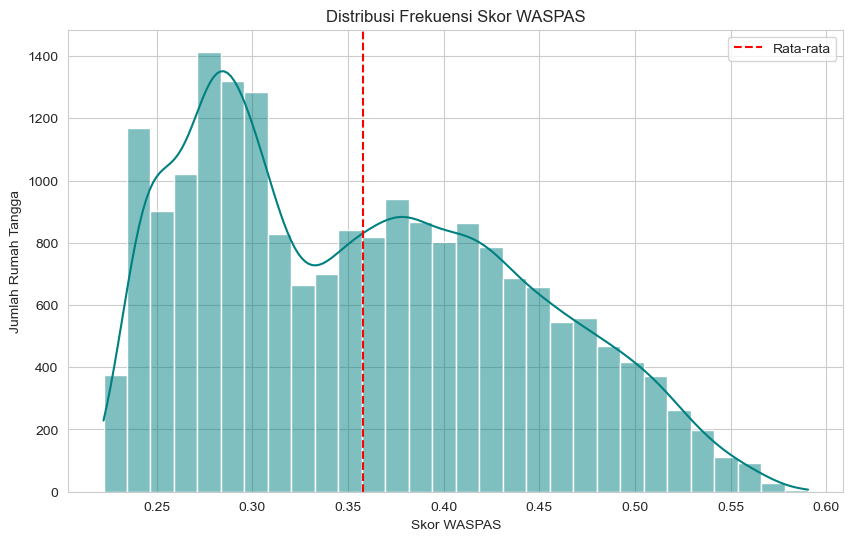

In [97]:
#Distribusi Frekuensi Skor WASPAS
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(data_gabung['WASPAS'], kde=True, bins=30, color='teal')
plt.title('Distribusi Frekuensi Skor WASPAS')
plt.xlabel('Skor WASPAS')
plt.ylabel('Jumlah Rumah Tangga')
plt.axvline(data_gabung['WASPAS'].mean(), color='red', linestyle='--', label='Rata-rata')
plt.legend()
plt.show()

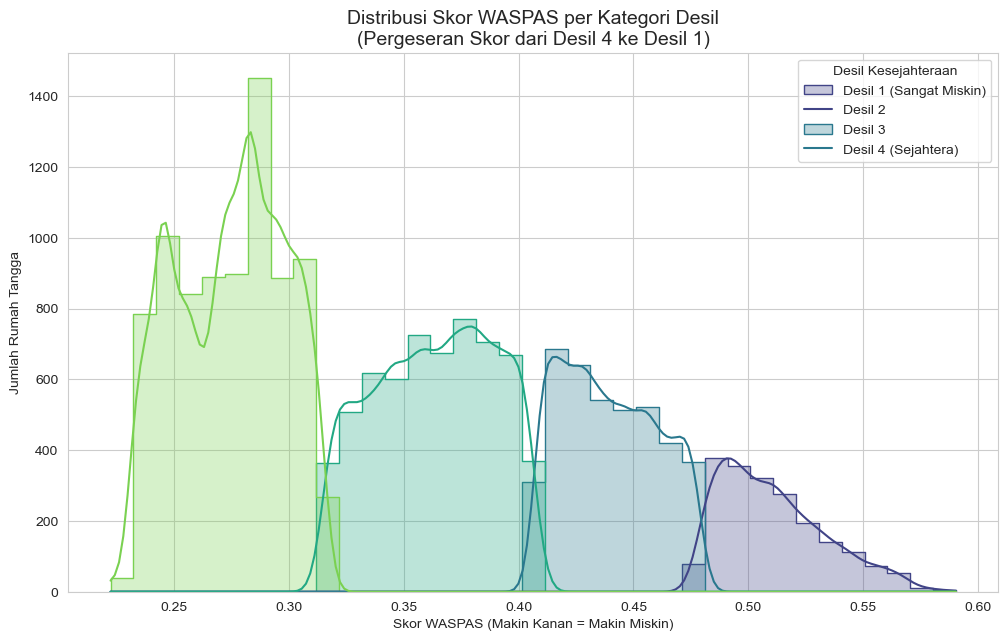

In [98]:
# Distribusi Skor WASPAS setiap desil
sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

data_gabung['Desil_Str'] = data_gabung['Desil'].astype(str)
sns.histplot(
    data=data_gabung,
    x='WASPAS',
    hue='Desil_Str',      # membedakan warna berdasarkan Desil
    hue_order=['4', '3', '2', '1'], # Urutan label
    palette='viridis_r',  
    kde=True,             # Tampilkan garis lengkung densitas
    element="step",       # Tampilan transparan agar yang di belakang terlihat
    alpha=0.3             # Transparansi
)

plt.title('Distribusi Skor WASPAS per Kategori Desil\n(Pergeseran Skor dari Desil 4 ke Desil 1)', fontsize=14)
plt.xlabel('Skor WASPAS (Makin Kanan = Makin Miskin)')
plt.ylabel('Jumlah Rumah Tangga')
plt.legend(title='Desil Kesejahteraan', labels=['Desil 1 (Sangat Miskin)', 'Desil 2', 'Desil 3', 'Desil 4 (Sejahtera)'])
plt.show()

In [99]:
# Statistik Utama Skor Fuzzy WASPAS
desc_stats = data_gabung['WASPAS'].describe()
mean_val = data_gabung['WASPAS'].mean()
median_val = data_gabung['WASPAS'].median()
std_dev = data_gabung['WASPAS'].std()
min_val = data_gabung['WASPAS'].min()
max_val = data_gabung['WASPAS'].max()
range_val = max_val - min_val
cv = (std_dev / mean_val) * 100  
skewness = data_gabung['WASPAS'].skew()

print("STATISTIK DESKRIPTIF SKOR WASPAS")
print(f"1. Nilai Minimum    : {min_val:.4f}")
print(f"2. Nilai Maksimum   : {max_val:.4f}")
print(f"3. Mean (Rata-rata) : {mean_val:.4f}")
print(f"4. Median (Tengah)  : {median_val:.4f}")
print(f"5. Standar Deviasi  : {std_dev:.4f}")
print("-" * 40)
print(f"Rentang (Range)     : {range_val:.4f}")
print(f"Koefisien Variasi   : {cv:.2f}%")
print(f"Skewness (Kemiringan): {skewness:.4f}")


print("\nINTERPRETASI ANALISIS")

# 1. Analisis Rentang (Range)
if range_val > 0.3:  # Threshold subjektif untuk skala 0-1
    print("[V] Rentang Skor: LEBAR.")
    print(f"    Selisih antara skor terendah dan tertinggi cukup besar ({range_val:.4f}).")
    print("    Ini menunjukkan adanya ketimpangan kesejahteraan yang signifikan antar rumah tangga.")
else:
    print("[X] Rentang Skor: SEMPIT.")
    print("    Kondisi kesejahteraan penduduk cenderung homogen (seragam).")

# 2. Analisis Konsentrasi (Central Tendency)
if abs(mean_val - median_val) < 0.01:
    print("[V] Konsentrasi: SIMETRIS (Normal).")
    print("    Nilai Mean dan Median hampir sama, data tersebar merata.")
elif mean_val > median_val:
    print("[V] Konsentrasi: MIRING KE KANAN (Positif).")
    print(f"    Mean ({mean_val:.4f}) > Median ({median_val:.4f}).")
    print("    Artinya, sebagian besar penduduk berkumpul di skor rendah (sejahtera),")
    print("    tetapi ada sekolompok kecil 'ekor panjang' dengan skor sangat tinggi (sangat miskin).")
else:
    print("[V] Konsentrasi: MIRING KE KIRI (Negatif).")
    print("    Mayoritas penduduk berkumpul di skor tinggi (miskin).")

# 3. Analisis Variasi untuk Segmentasi
if cv > 10:
    print("[V] Variasi: CUKUP BESAR (Heterogen).")
    print(f"    Koefisien Variasi sebesar {cv:.2f}% (>10%).")
    print("    Data sangat layak untuk dilakukan segmentasi (pengelompokan Desil 1-4).")
    print("    Perbedaan antar kelompok akan terlihat jelas/tegas.")
else:
    print("[X] Variasi: KECIL (Homogen).")
    print("    Data terlalu mirip satu sama lain, segmentasi mungkin kurang efektif.")

STATISTIK DESKRIPTIF SKOR WASPAS
1. Nilai Minimum    : 0.2223
2. Nilai Maksimum   : 0.5905
3. Mean (Rata-rata) : 0.3577
4. Median (Tengah)  : 0.3493
5. Standar Deviasi  : 0.0839
----------------------------------------
Rentang (Range)     : 0.3682
Koefisien Variasi   : 23.45%
Skewness (Kemiringan): 0.3919

INTERPRETASI ANALISIS
[V] Rentang Skor: LEBAR.
    Selisih antara skor terendah dan tertinggi cukup besar (0.3682).
    Ini menunjukkan adanya ketimpangan kesejahteraan yang signifikan antar rumah tangga.
[V] Konsentrasi: SIMETRIS (Normal).
    Nilai Mean dan Median hampir sama, data tersebar merata.
[V] Variasi: CUKUP BESAR (Heterogen).
    Koefisien Variasi sebesar 23.45% (>10%).
    Data sangat layak untuk dilakukan segmentasi (pengelompokan Desil 1-4).
    Perbedaan antar kelompok akan terlihat jelas/tegas.


In [100]:
data_gabung['WASPAS'].describe()

count    20000.000000
mean         0.357745
std          0.083900
min          0.222261
25%          0.283888
50%          0.349286
75%          0.421290
max          0.590452
Name: WASPAS, dtype: float64

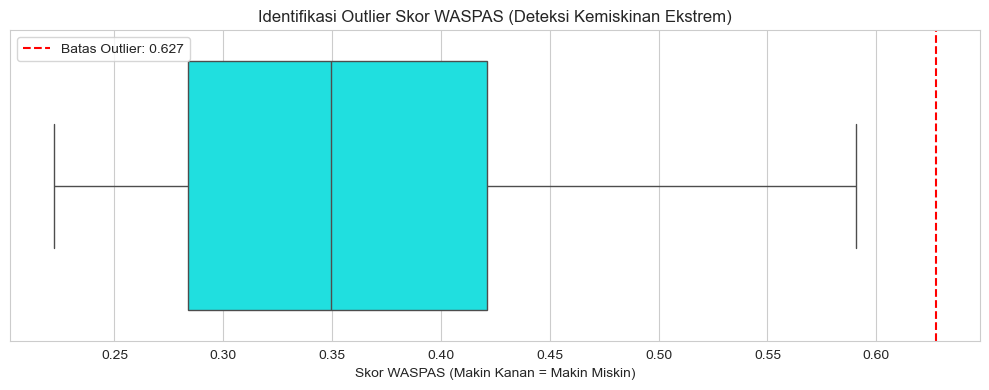

In [101]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=data_gabung['WASPAS'], color='cyan', 
            flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 5})

plt.title('Identifikasi Outlier Skor WASPAS (Deteksi Kemiskinan Ekstrem)')
plt.xlabel('Skor WASPAS (Makin Kanan = Makin Miskin)')

# Menambahkan garis batas (Threshold)
Q1 = data_gabung['WASPAS'].quantile(0.25)
Q3 = data_gabung['WASPAS'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

plt.axvline(upper_bound, color='red', linestyle='--', label=f'Batas Outlier: {upper_bound:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/1b/ryyx74w51b1fcx5dj4rxb0r80000gn/T/ipykernel_32973/1134649607.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='WASPAS', y='Kecamatan', data=data_gabung, order=order, palette='coolwarm')


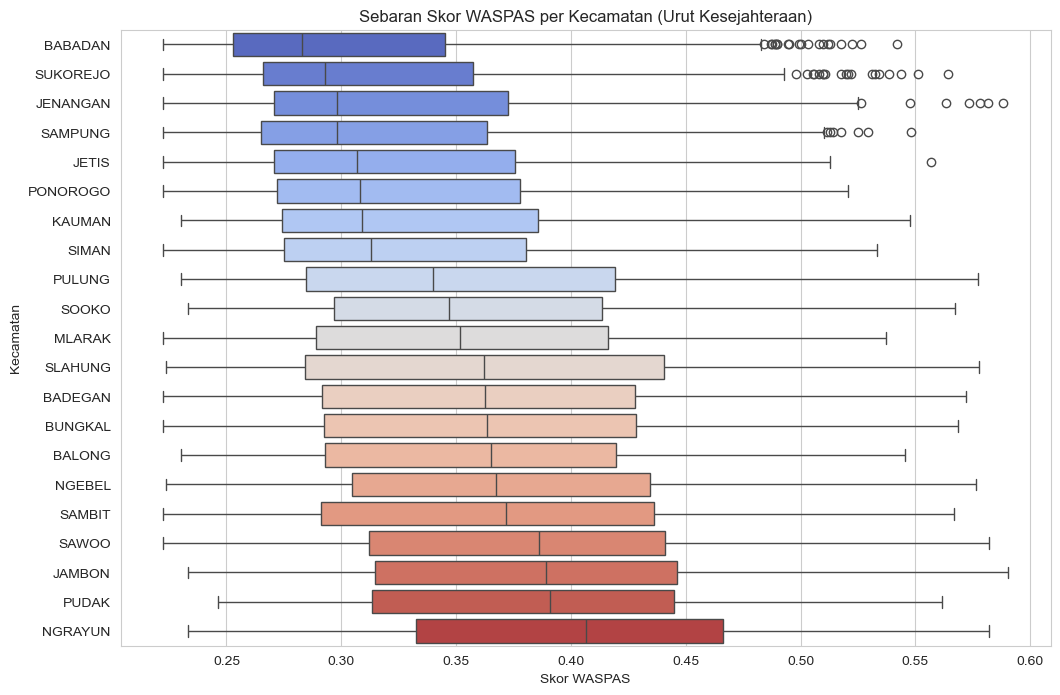

In [102]:
# Sebaran skor fuzzy waspas per kecamatan
plt.figure(figsize=(12, 8))
order = data_gabung.groupby('Kecamatan')['WASPAS'].median().sort_values().index
sns.boxplot(x='WASPAS', y='Kecamatan', data=data_gabung, order=order, palette='coolwarm')
plt.title('Sebaran Skor WASPAS per Kecamatan (Urut Kesejahteraan)')
plt.xlabel('Skor WASPAS')
plt.ylabel('Kecamatan')
plt.show()

/var/folders/1b/ryyx74w51b1fcx5dj4rxb0r80000gn/T/ipykernel_32973/988756584.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Desil', data=data_gabung, palette='coolwarm')


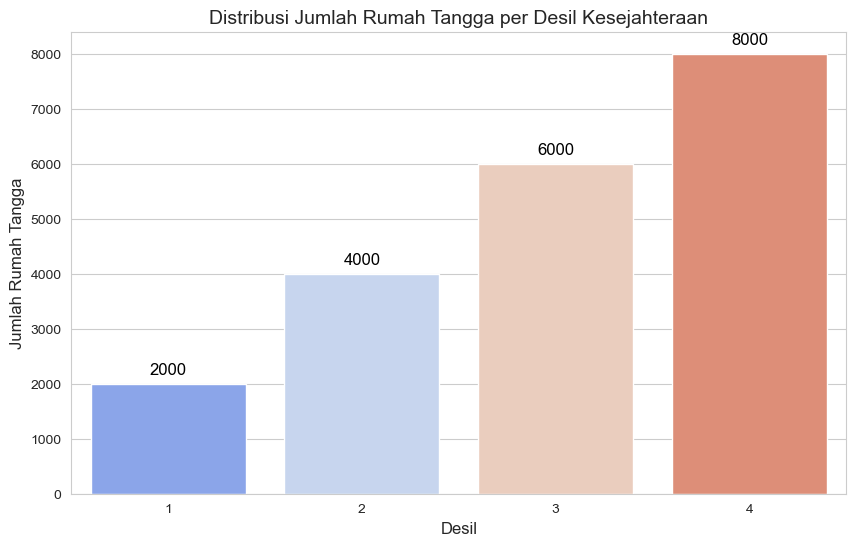

In [103]:
# Distribusi jumlah rumah tangga per desil
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Desil', data=data_gabung, palette='coolwarm')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=12, color='black', 
                xytext=(0, 10), 
                textcoords='offset points')

plt.title('Distribusi Jumlah Rumah Tangga per Desil Kesejahteraan', fontsize=14)
plt.xlabel('Desil', fontsize=12)
plt.ylabel('Jumlah Rumah Tangga', fontsize=12)
plt.show()

<Figure size 640x480 with 0 Axes>

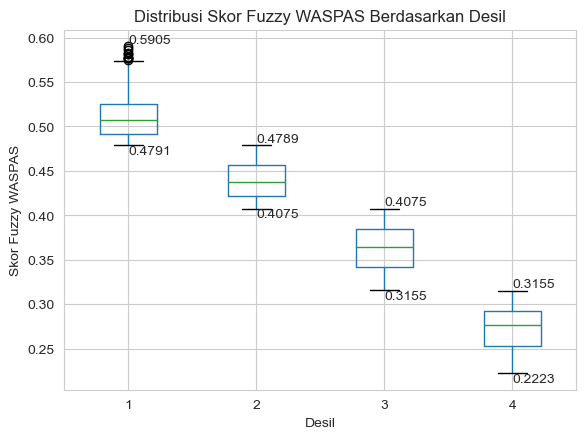

In [104]:
plt.figure()
data_gabung.boxplot(column='WASPAS', by='Desil')

# min dan max tiap desil
grouped = data_gabung.groupby('Desil')['WASPAS']
min_vals = grouped.min()
max_vals = grouped.max()

# tambahkan anotasi
for i, desil in enumerate(sorted(data_gabung['Desil'].unique()), start=1):
    plt.text(i, min_vals[desil], 
             f"{min_vals[desil]:.4f}", 
             verticalalignment='top')
    
    plt.text(i, max_vals[desil], 
             f"{max_vals[desil]:.4f}", 
             verticalalignment='bottom')

plt.title('Distribusi Skor Fuzzy WASPAS Berdasarkan Desil')
plt.suptitle('')
plt.xlabel('Desil')
plt.ylabel('Skor Fuzzy WASPAS')
plt.show()

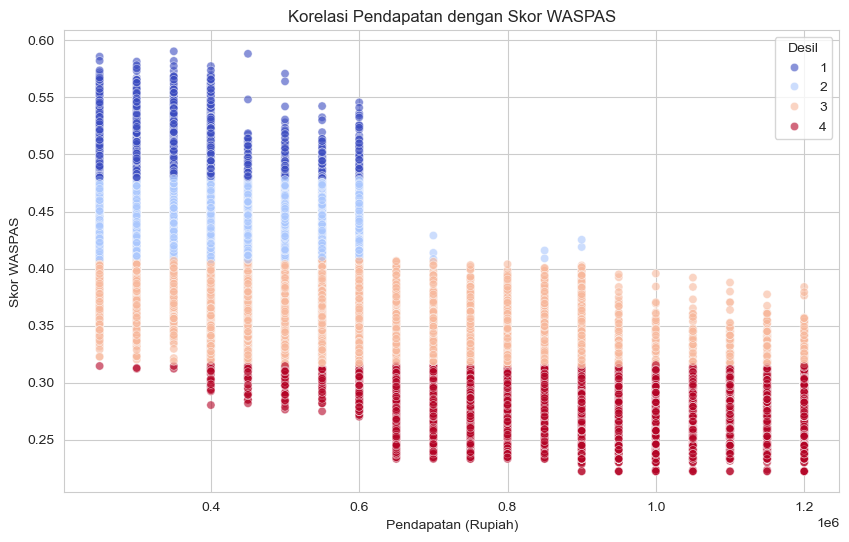

In [105]:
# Hubungan Pendapatan vs Skor WASPAS
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Pendapatan', y='WASPAS', data=data_gabung, hue='Desil', palette='coolwarm', alpha=0.6)
plt.title('Korelasi Pendapatan dengan Skor WASPAS')
plt.xlabel('Pendapatan (Rupiah)')
plt.ylabel('Skor WASPAS')
plt.show()

In [106]:
print("Mean WASPAS by Desil:")
print(data_gabung.groupby('Desil')['WASPAS'].mean())

Mean WASPAS by Desil:
Desil
1    0.510916
2    0.439726
3    0.363250
4    0.274334
Name: WASPAS, dtype: float64


In [107]:
# korelasi skor waaspas dengan bbrp kolom numerik
numeric_cols = ['Pendapatan', 'Frekuensi Makan Per Hari', 'Frekuensi Beli Pakaian', 
                'Frekuensi Makan Daging Susu Ayam', 'Luas Lantai', 'WASPAS']
corr_matrix = data_gabung[numeric_cols].corr()
print("\nCorrelation with WASPAS:")
print(corr_matrix['WASPAS'].sort_values(ascending=False))


Correlation with WASPAS:
WASPAS                              1.000000
Frekuensi Beli Pakaian             -0.522594
Frekuensi Makan Per Hari           -0.658651
Frekuensi Makan Daging Susu Ayam   -0.679640
Luas Lantai                        -0.734180
Pendapatan                         -0.796703
Name: WASPAS, dtype: float64


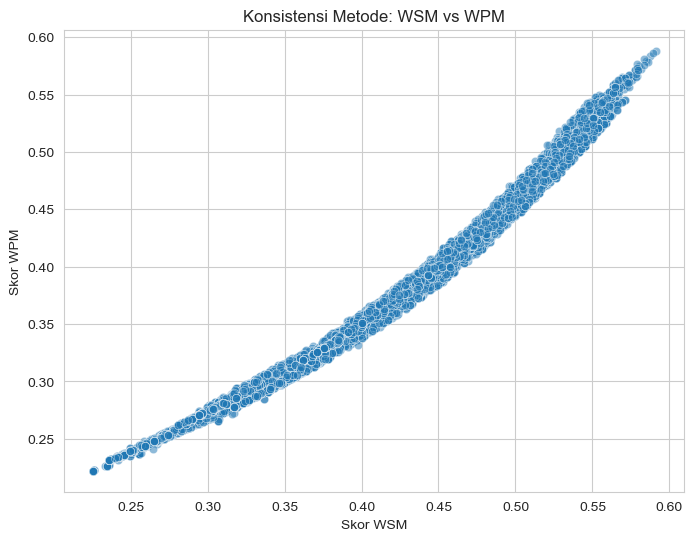

In [108]:
# distribusi skor WSM dan WPM
plt.figure(figsize=(8, 6))
sns.scatterplot(x='WSM', y='WPM', data=df, alpha=0.5)
plt.title('Konsistensi Metode: WSM vs WPM')
plt.xlabel('Skor WSM')
plt.ylabel('Skor WPM')
plt.show()

### Frekuensi Indikator Kemiskinan per Desil

In [109]:
# Tabel frekuensi Pendidikan berdasarkan Desil
tabel_pendidikan_desil = pd.crosstab(data_gabung['Desil'], data_gabung['Pendidikan'])
tabel_pendidikan_desil

Pendidikan,Mahasiswa Perguruan Tinggi,Siswa SD/sederajat,Siswa SMA/sederajat,Siswa SMP/sederajat,Tamat Perguruan Tinggi,Tamat SD/sederajat,Tamat SMA/sederajat,Tamat SMP/sederajat,Tidak tamat SD/sederajat,Tidak/belum sekolah
Desil,,,,,,,,,,
1,0,5,5,5,0,1071,48,269,354,243
2,1,15,9,14,3,2137,209,680,557,375
3,1,10,16,24,22,3072,577,1274,642,362
4,6,25,61,45,118,3309,1648,1834,698,256


In [110]:
tabel_makan_desil = pd.crosstab(data_gabung['Desil'], data_gabung['Frekuensi Makan Per Hari'])
tabel_makan_desil

Frekuensi Makan Per Hari,1,2,3
Desil,,,
1,1289,703,8
2,1949,1718,333
3,1226,3205,1569
4,0,3475,4525


In [111]:
tabel_pakaian_desil = pd.crosstab(data_gabung['Desil'], data_gabung['Frekuensi Beli Pakaian'])
tabel_pakaian_desil

Frekuensi Beli Pakaian,0,1,2,3
Desil,,,,
1,967,819,198,16
2,1514,1575,723,188
3,1006,2425,1800,769
4,27,2692,2731,2550


In [112]:
tabel_pendapatan_desil = pd.crosstab(data_gabung['Desil'], data_gabung['Pendapatan'])
tabel_pendapatan_desil

Pendapatan,250000,300000,350000,400000,450000,500000,550000,600000,650000,700000,750000,800000,850000,900000,950000,1000000,1050000,1100000,1150000,1200000
Desil,,,,,,,,,,,,,,,,,,,,
1,438,414,414,494,61,63,54,62,0,0,0,0,0,0,0,0,0,0,0,0
2,527,547,569,904,355,339,337,415,0,3,0,0,2,2,0,0,0,0,0,0
3,240,278,282,800,605,509,586,984,227,195,267,214,202,278,65,55,51,50,53,59
4,1,2,2,38,35,44,47,257,522,484,494,511,522,1203,637,698,612,654,624,613


In [113]:
tabel_simpanan_desil = pd.crosstab(data_gabung['Desil'], data_gabung['Simpanan'])
tabel_simpanan_desil

Simpanan,Tidak,Ya
Desil,,
1,1404,596
2,1871,2129
3,1134,4866
4,319,7681


In [114]:
tabel_simpanan_desil = pd.crosstab(data_gabung['Desil'], data_gabung['Jenis Dinding'])
tabel_simpanan_desil

Jenis Dinding,Bambu,Kayu/Papan,Lainnya,Seng,Tembok
Desil,,,,,
1,259,266,47,1,1427
2,300,373,102,5,3220
3,183,269,63,3,5482
4,80,112,27,2,7779


In [115]:
tabel_simpanan_desil = pd.crosstab(data_gabung['Desil'], data_gabung['Jenis Lantai'])
tabel_simpanan_desil

Jenis Lantai,Bambu,Kayu/Papan,Keramik/Granit/Marmer/Ubin/Tegel/Teraso,Lainnya,Semen,Tanah
Desil,,,,,,
1,5,3,152,37,738,1065
2,4,8,655,96,1596,1641
3,5,3,1974,135,2520,1363
4,2,1,4989,71,2432,505


In [116]:
tabel_simpanan_desil = pd.crosstab(data_gabung['Desil'], data_gabung['Sumber Penerangan'])
tabel_simpanan_desil

Sumber Penerangan,Genset/solar cell,Listrik Bersama,Listrik Pribadi > 900 Watt,Listrik Pribadi s/d 900 Watt,Non-Listrik
Desil,,,,,
1,0,448,305,1235,12
2,1,567,595,2830,7
3,0,539,796,4658,7
4,0,410,1370,6218,2


In [117]:
tabel_simpanan_desil = pd.crosstab(data_gabung['Desil'], data_gabung['Luas Lantai'])
tabel_simpanan_desil

Luas Lantai,5,6,7,8,9,10,11,12,13,14,15
Desil,,,,,,,,,,,
1,525,568,397,438,42,30,0,0,0,0,0
2,701,1097,837,829,249,250,15,13,9,0,0
3,325,1010,860,994,697,844,390,442,331,51,56
4,1,52,49,331,511,1158,1588,1603,1381,653,673


In [118]:
tabel_simpanan_desil = pd.crosstab(data_gabung['Desil'], data_gabung['Fasilitas BAB'])
tabel_simpanan_desil

Fasilitas BAB,Lainnya,"Tidak, Jamban Umum/Bersama","Ya, dengan Septic Tank","Ya, tanpa Septic Tank"
Desil,,,,
1,191,366,902,541
2,290,501,2449,760
3,195,407,4763,635
4,47,215,7431,307


In [119]:
tabel_simpanan_desil = pd.crosstab(data_gabung['Desil'], data_gabung['Sumber Air Minum'])
tabel_simpanan_desil

Sumber Air Minum,Air Hujan,Air Kemasan/Isi Ulang,"Air Permukaan (Sungai, Danau, dll)",Lainnya,Ledeng/PAM,Sumur Bor,Sumur Terlindung,Sumur Tidak Terlindung
Desil,,,,,,,,
1,1,3,424,312,83,237,743,197
2,1,10,511,454,259,705,1831,229
3,1,50,402,522,541,1391,2859,234
4,0,192,172,258,1202,2607,3440,129


In [120]:
tabel_protein_desil = pd.crosstab(data_gabung['Desil'], data_gabung['Frekuensi Makan Daging Susu Ayam'])
tabel_protein_desil

Frekuensi Makan Daging Susu Ayam,0,1,2,3,4,5
Desil,,,,,,
1,833,932,223,12,0,0
2,1258,1651,913,144,13,21
3,909,1395,1781,846,545,524
4,22,35,2046,2008,1943,1946


In [121]:
tabel_pendidikan_desil = pd.crosstab(
    data_gabung['Desil'], 
    data_gabung['Pendidikan']
).sort_index()

tabel_pendidikan_desil

Pendidikan,Mahasiswa Perguruan Tinggi,Siswa SD/sederajat,Siswa SMA/sederajat,Siswa SMP/sederajat,Tamat Perguruan Tinggi,Tamat SD/sederajat,Tamat SMA/sederajat,Tamat SMP/sederajat,Tidak tamat SD/sederajat,Tidak/belum sekolah
Desil,,,,,,,,,,
1,0,5,5,5,0,1071,48,269,354,243
2,1,15,9,14,3,2137,209,680,557,375
3,1,10,16,24,22,3072,577,1274,642,362
4,6,25,61,45,118,3309,1648,1834,698,256


In [122]:
# Crosstab jumlah
tabel_makan = pd.crosstab(
    data_gabung['Desil'], 
    data_gabung['Simpanan']
).sort_index()

# Hitung persentase per desil
tabel_makan_persen = tabel_makan.div(tabel_makan.sum(axis=1), axis=0) * 100

# Gabungkan jumlah + persentase
tabel_makan_final = tabel_makan.astype(str) + " (" + tabel_makan_persen.round(2).astype(str) + "%)"
tabel_makan_final

Simpanan,Tidak,Ya
Desil,,
1,1404 (70.2%),596 (29.8%)
2,1871 (46.78%),2129 (53.22%)
3,1134 (18.9%),4866 (81.1%)
4,319 (3.99%),7681 (96.01%)


In [123]:
tabel_makan = pd.crosstab(
    data_gabung1['Desil'], 
    data_gabung1['Frekuensi Beli Pakaian']
).sort_index()

# Hitung persentase per desil
tabel_makan_persen = tabel_makan.div(tabel_makan.sum(axis=1), axis=0) * 100

tabel_makan_final = tabel_makan.astype(str) + " (" + tabel_makan_persen.round(2).astype(str) + "%)"
tabel_makan_final

Frekuensi Beli Pakaian,0,1,2,3
Desil,,,,
1,967 (48.35%),819 (40.95%),198 (9.9%),16 (0.8%)
2,1514 (37.85%),1575 (39.38%),723 (18.08%),188 (4.7%)
3,1006 (16.77%),2425 (40.42%),1800 (30.0%),769 (12.82%)
4,27 (0.34%),2692 (33.65%),2731 (34.14%),2550 (31.87%)


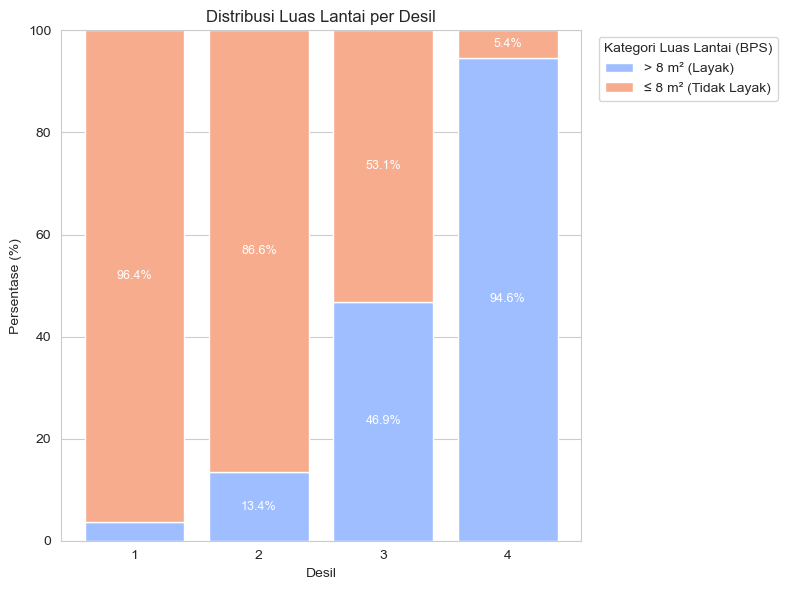

In [124]:
data_gabung['Luas Lantai'] = data_gabung['Luas Lantai'].apply(
    lambda x: 2 if x <= 8 else 1
)


tabel = pd.crosstab(
    data_gabung['Desil'],
    data_gabung['Luas Lantai']
).sort_index()


tabel_persen = tabel.div(tabel.sum(axis=1), axis=0) * 100

label_map = {
    1: "> 8 m² (Layak)",
    2: "≤ 8 m² (Tidak Layak)"
}


categories = sorted(tabel_persen.columns)
colors = plt.cm.coolwarm(np.linspace(0.3, 0.7, len(categories)))

plt.figure(figsize=(8,6))
bottom = np.zeros(len(tabel_persen))
for i, kategori in enumerate(categories):
    values = tabel_persen[kategori].values

    plt.bar(
        tabel_persen.index,
        values,
        bottom=bottom,
        color=colors[i],
        label=label_map.get(kategori, f"Kategori {kategori}")
    )

    # Tambahkan persen di tengah bar
    for j in range(len(values)):
        if values[j] > 5:  # biar tidak terlalu padat
            plt.text(
                j+1,
                bottom[j] + values[j]/2,
                f"{values[j]:.1f}%",
                ha='center',
                va='center',
                fontsize=9,
                color='white'
            )

    bottom += values

plt.xlabel("Desil")
plt.ylabel("Persentase (%)")
plt.title("Distribusi Luas Lantai per Desil")
plt.xticks(tabel_persen.index)
plt.ylim(0,100)

plt.legend(
    title="Kategori Luas Lantai (BPS)",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [125]:
tabel_makan = pd.crosstab(
    final_df['Desil'], 
    final_df['Pendapatan']
).sort_index()

# Hitung persentase per desil
tabel_makan_persen = tabel_makan.div(tabel_makan.sum(axis=1), axis=0) * 100

# Gabungkan jumlah + persentase
tabel_makan_final = tabel_makan.astype(str) + " (" + tabel_makan_persen.round(2).astype(str) + "%)"

display(tabel_makan_final)

Pendapatan,1,2
Desil,,
1,0 (0.0%),2000 (100.0%)
2,7 (0.18%),3993 (99.82%)
3,1716 (28.6%),4284 (71.4%)
4,7574 (94.68%),426 (5.32%)


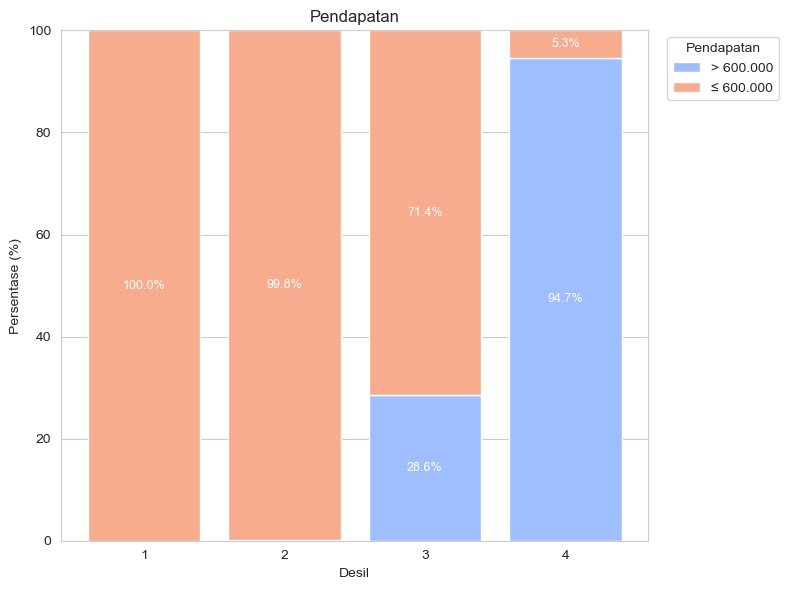

In [126]:
data_gabung['Pendapatan'] = data_gabung['Pendapatan'].apply(lambda x: 2 if x <= 600_000 else 1)

tabel = pd.crosstab(
    data_gabung['Desil'],
    data_gabung['Pendapatan']
).sort_index()

tabel_persen = tabel.div(tabel.sum(axis=1), axis=0) * 100

label_map = {
    1: "> 600.000",
    2: "≤ 600.000"
}

categories = sorted(tabel_persen.columns)
colors = plt.cm.coolwarm(np.linspace(0.3, 0.7, len(categories)))

plt.figure(figsize=(8,6))

bottom = np.zeros(len(tabel_persen))

for i, kategori in enumerate(categories):
    values = tabel_persen[kategori].values

    plt.bar(
        tabel_persen.index,
        values,
        bottom=bottom,
        color=colors[i],
        label=label_map.get(kategori, f"Kategori {kategori}")
    )

    # Tambahkan persen di tengah bar
    for j in range(len(values)):
        if values[j] > 5:  # biar tidak terlalu padat
            plt.text(
                j+1,
                bottom[j] + values[j]/2,
                f"{values[j]:.1f}%",
                ha='center',
                va='center',
                fontsize=9,
                color='white'
            )

    bottom += values


plt.xlabel("Desil")
plt.ylabel("Persentase (%)")
plt.title("Pendapatan")
plt.xticks(tabel_persen.index)
plt.ylim(0,100)

plt.legend(
    title="Pendapatan",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

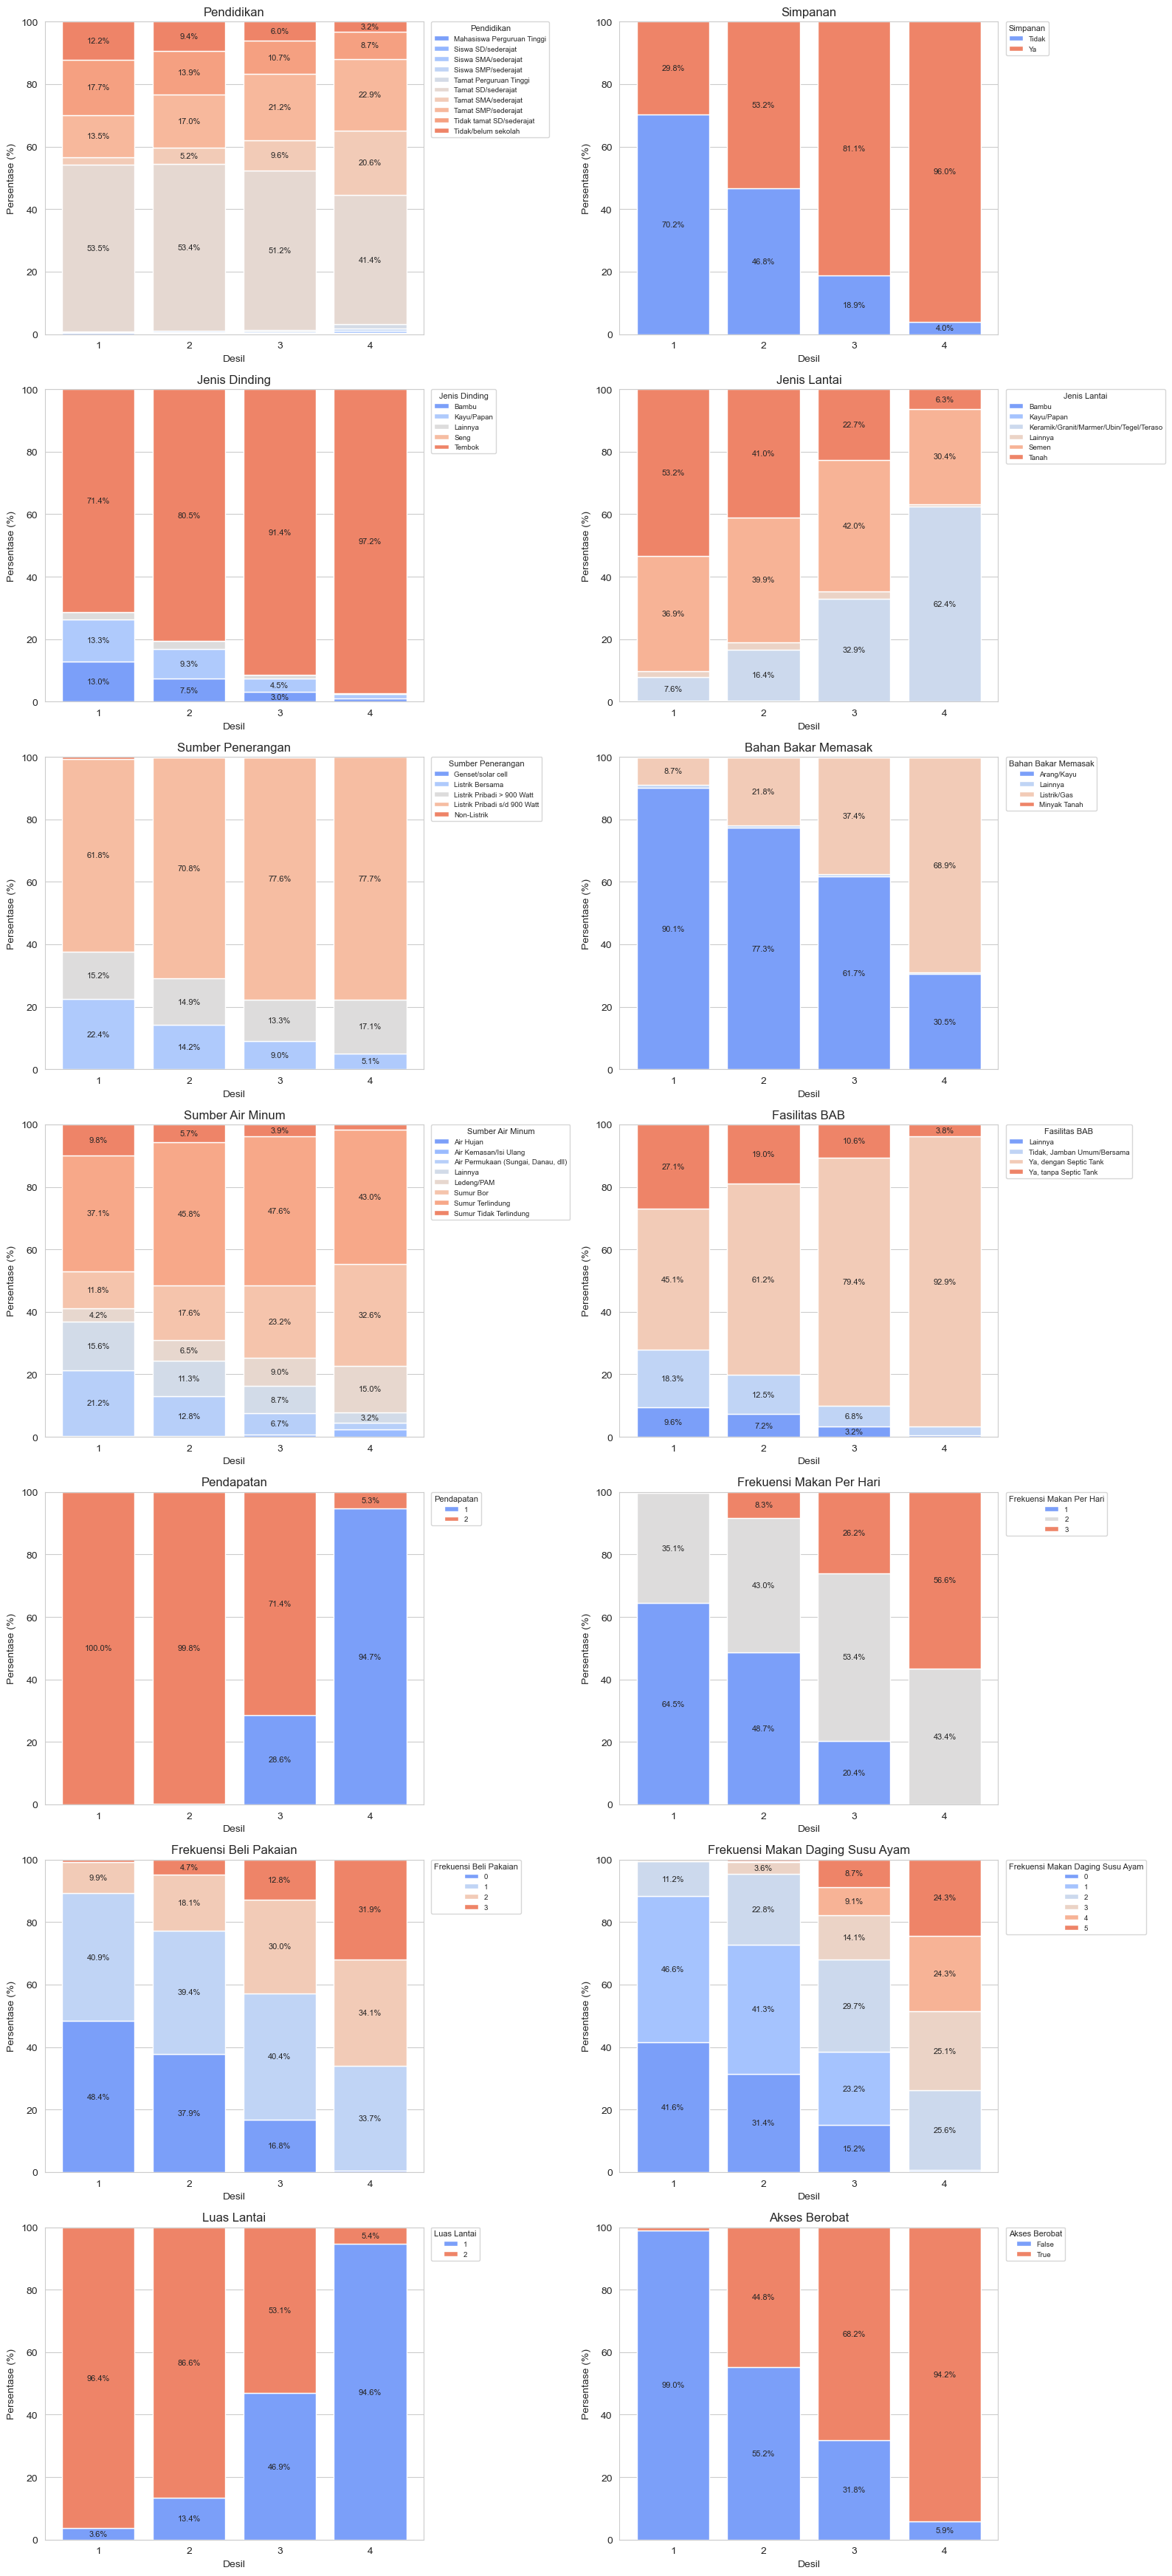

In [127]:
# Filter Desil 1–4
df_plot = data_gabung[data_gabung['Desil'].isin([1,2,3,4])]

variabel_list = [
    'Pendidikan',
    'Simpanan',
    'Jenis Dinding',
    'Jenis Lantai',
    'Sumber Penerangan',
    'Bahan Bakar Memasak',
    'Sumber Air Minum',
    'Fasilitas BAB',
    'Pendapatan',
    'Frekuensi Makan Per Hari',
    'Frekuensi Beli Pakaian',
    'Frekuensi Makan Daging Susu Ayam',
    'Luas Lantai',
    'Akses Berobat'
]

n_cols = 2
n_rows = math.ceil(len(variabel_list) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows))
axes = axes.flatten()

for i, variabel in enumerate(variabel_list):
    
    tabel = pd.crosstab(
        df_plot['Desil'], 
        df_plot[variabel]
    ).sort_index()
    
    tabel_persen = tabel.div(tabel.sum(axis=1), axis=0) * 100
    
    categories = tabel_persen.columns
    colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(categories)))
    
    bottom = np.zeros(len(tabel_persen))
    
    for j, kategori in enumerate(categories):
        values = tabel_persen[kategori].values
        
        bars = axes[i].bar(
            tabel_persen.index,
            values,
            bottom=bottom,
            color=colors[j]
        )
        
        # Label persen
        for k in range(len(values)):
            if values[k] > 3:
                axes[i].text(
                    tabel_persen.index[k],
                    bottom[k] + values[k]/2,
                    f"{values[k]:.1f}%",
                    ha='center',
                    va='center',
                    fontsize=8
                )
        
        bottom += values
    
    axes[i].set_title(variabel)
    axes[i].set_xlabel('Desil')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].set_ylim(0, 100)
    axes[i].set_xticks([1,2,3,4])
    
    # Legend dipindah ke luar
    axes[i].legend(
        categories,
        title=variabel,
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        fontsize=7,
        title_fontsize=8,
        borderaxespad=0
    )

# Hapus subplot kosong
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

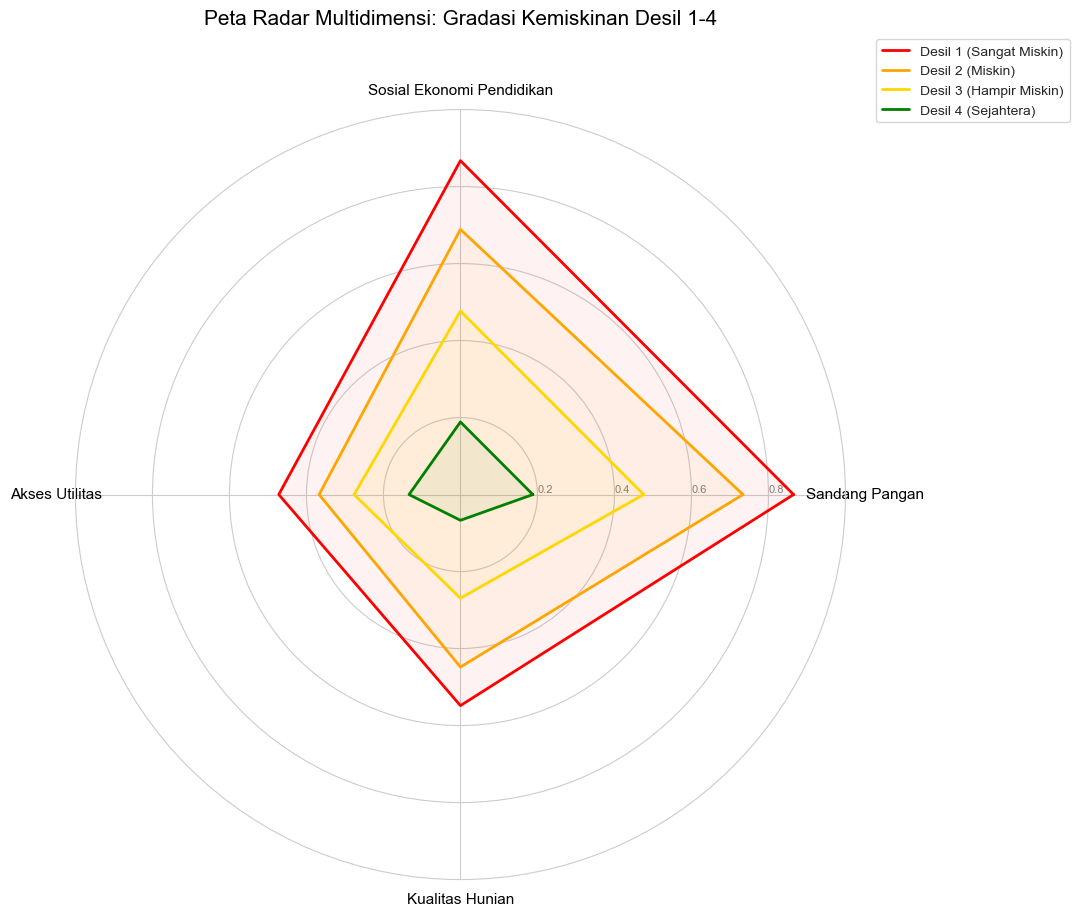

In [128]:
data_gabung['Pendidikan_Score'] = data_gabung['Pendidikan'].map({
    'Tidak/belum sekolah': 5, 'Tidak tamat SD/sederajat': 5,
    'Siswa SD/sederajat': 4, 'Tamat SD/sederajat': 4,
    'Siswa SMP/sederajat': 3, 'Tamat SMP/sederajat': 3,
    'Siswa SMA/sederajat': 2, 'Tamat SMA/sederajat': 2,
    'Mahasiswa Perguruan Tinggi': 1, 'Tamat Perguruan Tinggi': 1
})

data_gabung['Jenis Dinding_Score'] = data_gabung['Jenis Dinding'].map({
    'Tembok': 1, 'Seng': 2, 'Lainnya': 2, 'Kayu/Papan': 3, 'Bambu': 4
})

data_gabung['Jenis Lantai_Score'] = data_gabung['Jenis Lantai'].map({
    'Keramik/Granit/Marmer/Ubin/Tegel/Teraso': 1,
    'Semen': 2,
    'Lainnya': 3, 'Kayu/Papan': 3,
    'Bambu': 4,
    'Tanah': 5
})

data_gabung['Sumber Penerangan_Score'] = data_gabung['Sumber Penerangan'].map({
    'Listrik Pribadi s/d 900 Watt': 1,
    'Listrik Pribadi > 900 Watt': 1,
    'Non-Listrik': 2,
    'Listrik Bersama': 2,
    'Genset/solar cell': 2
})

data_gabung['Bahan Bakar Memasak_Score'] = data_gabung['Bahan Bakar Memasak'].map({
    'Listrik/Gas': 1, 'Minyak Tanah': 2, 'Arang/Kayu': 3, 'Lainnya': 2
})

data_gabung['Sumber Air Minum_Score'] = data_gabung['Sumber Air Minum'].map({
    'Ledeng/PAM': 1, 'Air Kemasan/Isi Ulang': 1, 'Sumur Bor': 1, 'Sumur Terlindung': 1,
    'Sumur Tidak Terlindung': 2, 'Air Permukaan (Sungai, Danau, dll)': 3,
    'Air Hujan': 4, 'Lainnya': 3
})

data_gabung['Fasilitas BAB_Score'] = data_gabung['Fasilitas BAB'].map({
    'Ya, dengan Septic Tank': 1,
    'Ya, tanpa Septic Tank': 2,
    'Lainnya': 2,
    'Tidak, Jamban Umum/Bersama': 3
})

data_gabung['Simpanan_Score'] = data_gabung['Simpanan'].map({'Ya': 1, 'Tidak': 2})
data_gabung['Akses Berobat_Score'] = data_gabung['Akses Berobat'].apply(lambda x: 1 if x else 2)
data_gabung['Pendapatan_Score'] = data_gabung['Pendapatan']
data_gabung['Luas Lantai_Score'] = data_gabung['Luas Lantai']
data_gabung['Frekuensi Beli Pakaian_Score'] = data_gabung['Frekuensi Beli Pakaian'].apply(lambda x: 2 if x <= 1 else 1)
data_gabung['Frekuensi Makan Daging Susu Ayam_Score'] = data_gabung['Frekuensi Makan Daging Susu Ayam'].apply(lambda x: 2 if x <= 1 else 1)
data_gabung['Frekuensi Makan Per Hari_Score'] = data_gabung['Frekuensi Makan Per Hari'].map({3: 1, 2: 2, 1: 3})


# NORMALISASI 0-1
cols_score = [c for c in data_gabung.columns if '_Score' in c]
for col in cols_score:
    min_val = data_gabung[col].min()
    max_val = data_gabung[col].max()
    if max_val > min_val:
        data_gabung[col + '_Norm'] = (data_gabung[col] - min_val) / (max_val - min_val)
    else:
        data_gabung[col + '_Norm'] = 0

# Mapping Dimensi
dimensi = {
    "Sandang Pangan": [
        "Frekuensi Makan Per Hari_Score_Norm",
        "Frekuensi Makan Daging Susu Ayam_Score_Norm",
        "Frekuensi Beli Pakaian_Score_Norm"
    ],
    "Sosial Ekonomi Pendidikan": [
        "Akses Berobat_Score_Norm",
        "Pendapatan_Score_Norm",
        "Simpanan_Score_Norm",
        "Pendidikan_Score_Norm"
    ],
    "Akses Utilitas": [
        "Sumber Penerangan_Score_Norm",
        "Bahan Bakar Memasak_Score_Norm",
        "Sumber Air Minum_Score_Norm"
    ],
    "Kualitas Hunian": [
        "Fasilitas BAB_Score_Norm",
        "Luas Lantai_Score_Norm",
        "Jenis Dinding_Score_Norm",
        "Jenis Lantai_Score_Norm"
    ]
}

# Hitung rata-rata per dimensi
dim_df = pd.DataFrame()
dim_df['Desil'] = data_gabung['Desil']
for nama_dim, kolom in dimensi.items():
    dim_df[nama_dim] = data_gabung[kolom].mean(axis=1)

radar_data = dim_df.groupby('Desil').mean()

# Radar Chart
def make_radar_all(data, title):
    categories = list(data.columns)
    N = len(categories)
    
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)
    
    plt.xticks(angles[:-1], categories, color='black', size=11)
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2","0.4","0.6","0.8"], color="grey", size=8)
    plt.ylim(0, 1)
    
    # Loop untuk setiap Desil
    colors = ['red', 'orange', 'gold', 'green'] # Desil 1–4
    labels = ['Desil 1 (Sangat Miskin)', 'Desil 2 (Miskin)', 'Desil 3 (Hampir Miskin)', 'Desil 4 (Sejahtera)']
    
    for i, desil_num in enumerate([1, 2, 3, 4]):
        val = data.loc[desil_num].values.flatten().tolist()
        val += val[:1]
        ax.plot(angles, val, linewidth=2, linestyle='solid', label=labels[i], color=colors[i])
        ax.fill(angles, val, colors[i], alpha=0.05)
    
    plt.title(title, size=15, color='black', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

make_radar_all(radar_data, "Peta Radar Multidimensi: Gradasi Kemiskinan Desil 1-4")

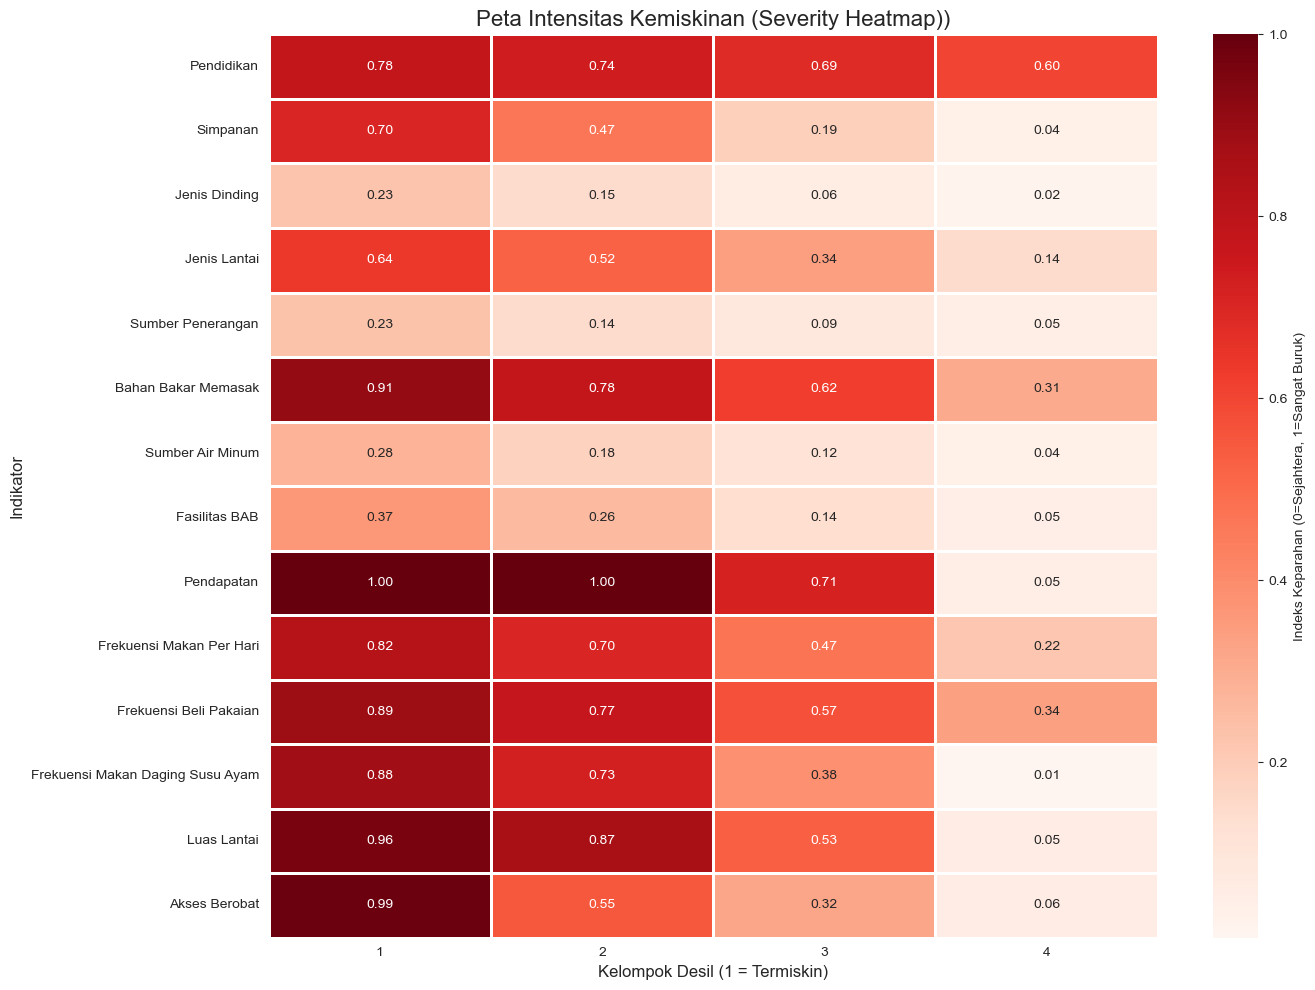

--- Tabel Skor Intensitas Rata-rata per Desil ---
Desil                                 1      2      3      4
Pendidikan                        0.777  0.737  0.685  0.603
Simpanan                          0.702  0.468  0.189  0.040
Jenis Dinding                     0.226  0.146  0.064  0.021
Jenis Lantai                      0.637  0.524  0.344  0.144
Sumber Penerangan                 0.230  0.144  0.091  0.052
Bahan Bakar Memasak               0.907  0.777  0.622  0.308
Sumber Air Minum                  0.279  0.180  0.116  0.041
Fasilitas BAB                     0.366  0.256  0.137  0.049
Pendapatan                        1.000  0.998  0.714  0.053
Frekuensi Makan Per Hari          0.820  0.702  0.471  0.217
Frekuensi Beli Pakaian            0.893  0.772  0.572  0.340
Frekuensi Makan Daging Susu Ayam  0.882  0.727  0.384  0.007
Luas Lantai                       0.964  0.866  0.532  0.054
Akses Berobat                     0.990  0.552  0.318  0.058


In [129]:
# Pendidikan (1-5)
data_gabung['Pendidikan'] = data_gabung['Pendidikan'].map({
    'Tidak/belum sekolah': 5, 'Tidak tamat SD/sederajat': 5,
    'Siswa SD/sederajat': 4, 'Tamat SD/sederajat': 4,
    'Siswa SMP/sederajat': 3, 'Tamat SMP/sederajat': 3,
    'Siswa SMA/sederajat': 2, 'Tamat SMA/sederajat': 2,
    'Mahasiswa Perguruan Tinggi': 1, 'Tamat Perguruan Tinggi': 1
})

# Lantai (1-5)
data_gabung['Jenis Lantai'] = data_gabung['Jenis Lantai'].map({
    'Keramik/Granit/Marmer/Ubin/Tegel/Teraso': 1, 
    'Semen': 2, 'Lainnya': 3, 'Kayu/Papan': 3, 'Bambu': 4, 'Tanah': 5
})

# Dinding (1-4)
data_gabung['Jenis Dinding'] = data_gabung['Jenis Dinding'].map({
    'Tembok': 1, 'Seng': 2, 'Lainnya': 2, 'Kayu/Papan': 3, 'Bambu': 4
})

# Variabel Lainnya (sesuai mapping Anda)
data_gabung['Sumber Penerangan'] = data_gabung['Sumber Penerangan'].map({
    'Listrik Pribadi s/d 900 Watt': 1, 
    'Listrik Pribadi > 900 Watt': 1, 
    'Non-Listrik': 2, 
    'Listrik Bersama': 2, 
    'Genset/solar cell': 2
})
data_gabung['Bahan Bakar Memasak'] = data_gabung['Bahan Bakar Memasak'].map({
    'Listrik/Gas': 1, 'Minyak Tanah': 2, 'Arang/Kayu': 3, 'Lainnya': 2
})
data_gabung['Sumber Air Minum'] = data_gabung['Sumber Air Minum'].map({
    'Ledeng/PAM': 1, 'Air Kemasan/Isi Ulang': 1, 'Sumur Bor': 1, 'Sumur Terlindung': 1,
    'Sumur Tidak Terlindung': 2, 'Air Permukaan (Sungai, Danau, dll)': 3,
    'Air Hujan': 4, 'Lainnya': 3
})
data_gabung['Fasilitas BAB'] = data_gabung['Fasilitas BAB'].map({
    'Ya, dengan Septic Tank': 1, 'Ya, tanpa Septic Tank': 2, 
    'Lainnya': 2, 'Tidak, Jamban Umum/Bersama': 3
})
data_gabung['Simpanan'] = data_gabung['Simpanan'].map({'Ya': 1, 'Tidak': 2})
data_gabung['Akses Berobat'] = data_gabung['Akses Berobat'].apply(lambda x: 1 if x == True else 2)
data_gabung['Pendapatan'] = data_gabung['Pendapatan']
data_gabung['Luas Lantai'] = data_gabung['Luas Lantai']
data_gabung['Frekuensi Beli Pakaian'] = data_gabung['Frekuensi Beli Pakaian'].apply(lambda x: 2 if x <= 1 else 1)
data_gabung['Frekuensi Makan Daging Susu Ayam'] = data_gabung['Frekuensi Makan Daging Susu Ayam'].apply(lambda x: 2 if x <= 1 else 1)
data_gabung['Frekuensi Makan Per Hari'] = data_gabung['Frekuensi Makan Per Hari'].map({3: 1, 2: 2, 1: 3})

# NORMALISASI
cols_target = [
    'Pendidikan', 'Simpanan', 'Jenis Dinding', 'Jenis Lantai', 
    'Sumber Penerangan', 'Bahan Bakar Memasak', 'Sumber Air Minum', 
    'Fasilitas BAB', 'Pendapatan', 'Frekuensi Makan Per Hari', 
    'Frekuensi Beli Pakaian', 'Frekuensi Makan Daging Susu Ayam', 
    'Luas Lantai', 'Akses Berobat'
]

for col in cols_target:
    min_val = data_gabung[col].min()
    max_val = data_gabung[col].max()
    if max_val > min_val:
        data_gabung[col] = (data_gabung[col] - min_val) / (max_val - min_val)
    else:
        data_gabung[col] = 0

# HEATMAP BERDASARKAN SKOR RATA-RATA
heatmap_data = data_gabung.groupby('Desil')[cols_target].mean()

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data.T, annot=True, fmt=".2f", cmap="Reds", 
            linewidths=1, linecolor='white',
            cbar_kws={'label': 'Indeks Keparahan (0=Sejahtera, 1=Sangat Buruk)'})

plt.title('Peta Intensitas Kemiskinan (Severity Heatmap))', fontsize=16)
plt.xlabel('Kelompok Desil (1 = Termiskin)', fontsize=12)
plt.ylabel('Indikator', fontsize=12)
plt.tight_layout()
plt.show()

print("--- Tabel Skor Intensitas Rata-rata per Desil ---")
print(heatmap_data.T.round(3))

In [130]:
dim_df = pd.DataFrame()
dim_df['Desil'] = data_gabung['Desil']

for nama_dim, kolom in dimensi.items():
    dim_df[nama_dim] = data_gabung[kolom].mean(axis=1)

hasil_akhir = dim_df.groupby('Desil').mean()

print("=== TABEL SKOR INDEKS DEPRIVASI MULTIDIMENSI PER DESIL ===")
print("(Skala: 0 = Sangat Sejahtera, 1 = Sangat Buruk)")
hasil_akhir.round(4)

=== TABEL SKOR INDEKS DEPRIVASI MULTIDIMENSI PER DESIL ===
(Skala: 0 = Sangat Sejahtera, 1 = Sangat Buruk)


,Sandang Pangan,Sosial Ekonomi Pendidikan,Akses Utilitas,Kualitas Hunian
Desil,,,,
1,0.8652,0.8673,0.4719,0.5482
2,0.7338,0.6888,0.3671,0.4481
3,0.4758,0.4766,0.2762,0.2692
4,0.1881,0.1886,0.1336,0.0669


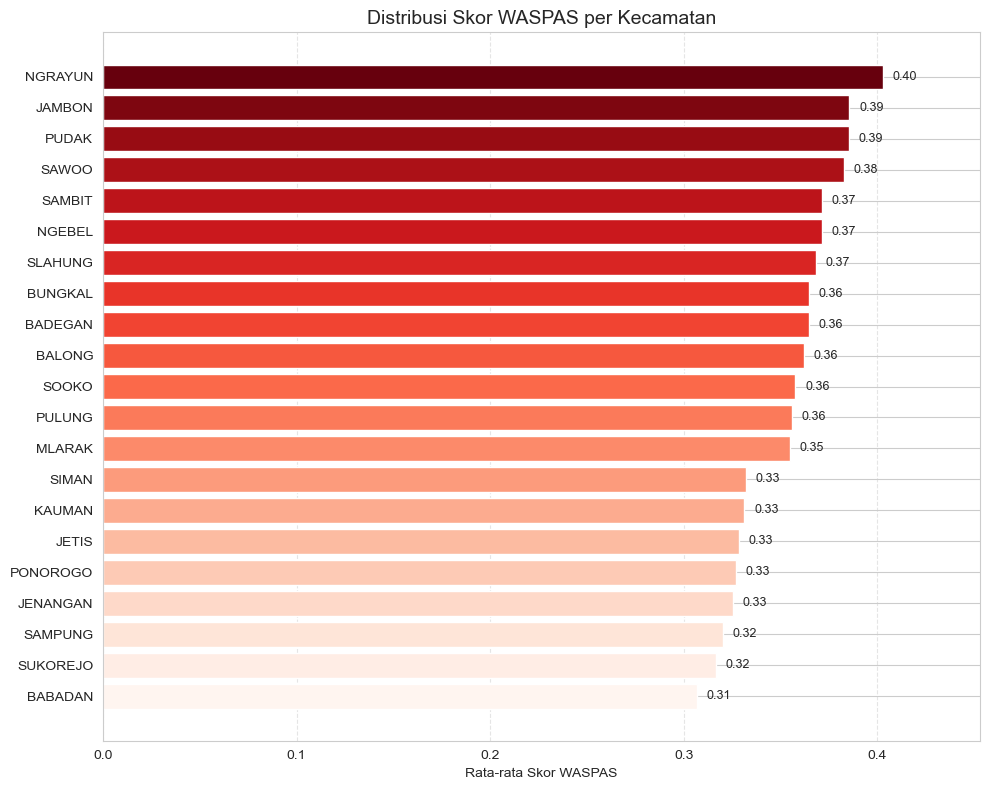

In [131]:
# Hitung rata-rata WASPAS per Kecamatan
waspas_kec = data_gabung1.groupby('Kecamatan')['WASPAS'].mean().sort_values(ascending=True)  # ascending biar horizontal

# Gradasi merah tua → merah muda
cmap = plt.get_cmap("Reds")
colors = cmap(np.linspace(0, 1, len(waspas_kec)))

plt.figure(figsize=(10,8))
bars = plt.barh(waspas_kec.index, waspas_kec.values, color=colors)

# Tambahkan nilai di samping bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, f"{width:.2f}", va='center', fontsize=9)

plt.xlabel("Rata-rata Skor WASPAS")
plt.title("Distribusi Skor WASPAS per Kecamatan", fontsize=14)
plt.xlim(0, waspas_kec.max() + 0.05)  # skala x pas
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [132]:
waspas_kec = data_gabung1.groupby('Kecamatan')['WASPAS'].mean().sort_values(ascending=True)  # ascending biar horizontal
waspas_kec

Kecamatan
BABADAN     0.306624
SUKOREJO    0.316723
SAMPUNG     0.320250
JENANGAN    0.325620
PONOROGO    0.327048
JETIS       0.328510
KAUMAN      0.331337
SIMAN       0.332136
MLARAK      0.354964
PULUNG      0.355741
SOOKO       0.357711
BALONG      0.362279
BADEGAN     0.364682
BUNGKAL     0.364772
SLAHUNG     0.368370
NGEBEL      0.371484
SAMBIT      0.371490
SAWOO       0.382654
PUDAK       0.385347
JAMBON      0.385577
NGRAYUN     0.403060
Name: WASPAS, dtype: float64